# Italy Geolocalization Benchmark

Production-grade evaluation pipeline comparing:
- **GeoClipItaly (fine-tuned)** — LoRA-adapted CLIP + GPS regression head (V3.3)
- **GeoCLIP retrieval (Italy-constrained)** — pretrained GeoCLIP, gallery filtered to Italy GPS cells *(base model)*
- **GeoEstimation (ISNs)** — TIBHannover EfficientNet-B4, S2-cell classification, Italy-constrained *(optional)*
- **GeoCLIP retrieval (global)** — full 100K gallery, ablation only *(disabled by default)*

Follows the **GeoCLIP paper (NeurIPS 2023)** evaluation protocol, adapted for Italy:

| Paper threshold | Scale | Italy-adapted note |
|---|---|---|
| 1 km | Street | Kept |
| 25 km | City | Kept |
| 200 km | Region | Kept |
| 2500 km | Country | **Dropped** — trivially ~100 % within Italy (max span ~1,200 km); replaced by **100 km** |

## Models

| Model | Role | Notes |
|-------|------|-------|
| `geoclip_italy_finetuned` | **Primary** — our fine-tuned model | LoRA rank-16, regression head |
| `geoclip_retrieval_italy` | **Base model** — always included | Italy-constrained gallery |
| `geo_estimation_italy` | **ISNs equivalent** from GeoCLIP paper | Opt-in: `INCLUDE_GEOESTIMATION = True` |
| `geoclip_retrieval_global` | **Ablation only** | Opt-in: `INCLUDE_GLOBAL_GEOCLIP = True` |

## Datasets

| Key | Description | Status |
|-----|-------------|--------|
| `osv5m` | Fixed OSV5M Italy test split (1,397 images, ≥1 km train separation by design) | Primary — already prepared |
| `im2gps` | IM2GPS3k filtered to Italy (~20–60 images) | Optional — see Section 1 |
| `yfcc26k` | YFCC26k filtered to Italy (~150–400 images) | Optional — see Section 1 |

## Run order

| # | Section | Every session? |
|---|---------|---------------|
| 0 | Install | Yes |
| 1 | Config & Drive | Yes — edit paths here |
| 2 | Package import | Yes |
| 3 | Datasets | Yes (fast if cached) |
| 4 | Inference | Yes — main eval loop (~10–20 min on T4) |
| 5 | Metrics | After inference |
| 6 | Visualizations | After inference |

In [1]:
# Install dependencies — run every Colab session
%pip install -q geoclip peft torch torchvision transformers pandas scikit-learn tqdm folium seaborn matplotlib geopandas shapely geopy Pillow huggingface_hub
%pip uninstall -y -q torchao

# Optional: GeoEstimation (ISNs equivalent, TIBHannover) — needed only when INCLUDE_GEOESTIMATION = True
# 1. Uncomment the line below and run this cell.
# 2. Runtime → Restart session.
# 3. Re-run all cells from the top.
# %pip install -q git+https://github.com/TIBHannover/GeoEstimation.git

print("Packages ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 MB 18.5 MB/s eta 0:00:00
Packages ready.


In [2]:
import os

# ============================================================
# GLOBAL CONFIGURATION — edit ONLY this cell
# ============================================================

DRIVE_BASE = "/content/drive/MyDrive/Vision_Project_2026"

# Fine-tuned checkpoint (V3.3)
CHECKPOINT_DIR      = f"{DRIVE_BASE}/checkpoints_v3_3"
CHECKPOINT_FILENAME = "geoclip_italy_BEST.pth"

# ── Datasets ─────────────────────────────────────────────────
# osv5m   : Fixed 1,397-image Italy test split (primary — no download needed)
# im2gps  : IM2GPS3k filtered to Italy (~20-60 images) — zip + CSV already on Drive
# yfcc26k : YFCC26k filtered to Italy (~150-400 images) — see Section 1 for download
DATASETS = ("osv5m", "im2gps")

# ── Dataset paths ─────────────────────────────────────────────
# IM2GPS3k: folder on Drive containing the zip + im2gps3k_places365.csv
IM2GPS_ROOT    = f"{DRIVE_BASE}/img2gps3k"   # folder name as uploaded to Drive
IM2GPS_IMGDIR  = "im2gps3ktest"              # subfolder created when zip is extracted

# ── Inference settings ───────────────────────────────────────
N_TEST_SAMPLES = None   # None = full test set; int = cap (e.g., 200 for smoke-test)
USE_TTA        = True   # Test-time augmentation: average N_TTA_VIEWS augmented views
N_TTA_VIEWS    = 6
BATCH_SIZE     = 32
NUM_WORKERS    = 2      # T4 has 2 vCPUs

# ── Model selection ──────────────────────────────────────────
# Always included:
#   geoclip_italy_finetuned   — our fine-tuned LoRA regression model (V3.3)
#   geoclip_retrieval_italy   — pretrained GeoCLIP, Italy-constrained gallery (base model)

# StreetCLIP (Haas et al. 2023, geolocal/StreetCLIP on HuggingFace)
# CLIP ViT-L/14 fine-tuned on geolocalized images; retrieval over Italy GPS text gallery.
# No extra install needed — transformers is already a geoclip dependency.
INCLUDE_STREETCLIP = True

# GeoEstimation = TIBHannover ISNs equivalent (EfficientNet-B4, S2-cell classification).
# Requires: uncomment the %pip install line in the install cell above, then restart session.
INCLUDE_GEOESTIMATION = False

# Global (unconstrained) GeoCLIP gallery — needed for the paper's headline comparison
# (fine-tuned vs. GeoCLIP-as-shipped) and for the labeled 3-way scatter/confusion figures
# in Section 4. Adds one extra full inference pass over the test set.
INCLUDE_GLOBAL_GEOCLIP = True

# Output directory for CSVs, plots, maps
OUTPUT_DIR = f"{DRIVE_BASE}/benchmark_results"

print("Config loaded.")
print(f"  Checkpoint       : {CHECKPOINT_DIR}/{CHECKPOINT_FILENAME}")
print(f"  Datasets         : {DATASETS}")
print(f"  IM2GPS root      : {IM2GPS_ROOT}")
print(f"  TTA              : {USE_TTA} x{N_TTA_VIEWS} views")
print(f"  StreetCLIP       : {INCLUDE_STREETCLIP}")
print(f"  GeoEstimation    : {INCLUDE_GEOESTIMATION}  ← needs manual pip install (see Cell 01)")
print(f"  Global GeoCLIP   : {INCLUDE_GLOBAL_GEOCLIP}")
print(f"  Output dir       : {OUTPUT_DIR}")

Config loaded.
  Checkpoint       : /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_3/geoclip_italy_BEST.pth
  Datasets         : ('osv5m', 'im2gps')
  IM2GPS root      : /content/drive/MyDrive/Vision_Project_2026/img2gps3k
  TTA              : True x6 views
  StreetCLIP       : True
  GeoEstimation    : False  ← needs manual pip install (see Cell 01)
  Global GeoCLIP   : True
  Output dir       : /content/drive/MyDrive/Vision_Project_2026/benchmark_results


In [3]:
from google.colab import drive
import os, shutil

if os.path.exists("/content/drive") and os.path.ismount("/content/drive"):
    print("Drive already mounted. Unmounting...")
    drive.flush_and_unmount()

if os.path.exists("/content/drive") and os.listdir("/content/drive"):
    for item in os.listdir("/content/drive"):
        p = os.path.join("/content/drive", item)
        if os.path.isfile(p) or os.path.islink(p):
            os.unlink(p)
        elif os.path.isdir(p):
            shutil.rmtree(p)

print("Mounting Google Drive...")
drive.mount("/content/drive", force_remount=True)

Mounting Google Drive...
Mounted at /content/drive


In [4]:
import os
import sys

REPO_ROOT = os.environ.get("VISION_PROJECT_ROOT", "")
_candidates = [REPO_ROOT, DRIVE_BASE, "/content/vision_project"]
for _cand in _candidates:
    if _cand and os.path.isdir(os.path.join(_cand, "benchmarking")):
        REPO_ROOT = _cand
        break

if not REPO_ROOT or not os.path.isdir(os.path.join(REPO_ROOT, "benchmarking")):
    raise RuntimeError(
        "benchmarking/ package not found.\n"
        "Copy the benchmarking/ folder from the repo to Drive under DRIVE_BASE, "
        "or set VISION_PROJECT_ROOT env var to the repo root, then re-run."
    )
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from benchmarking.config import (
    BenchmarkConfig, check_package_version, BENCHMARK_PACKAGE_VERSION
)
from benchmarking.runner     import run_benchmark, regenerate_plots
from benchmarking.spatial    import ItalySpatialFilter
from benchmarking.metrics    import (
    compute_metrics, compute_errors_km,
    paper_metrics_table, metrics_table,
)
from benchmarking.open_domain import (
    ensure_im2gps_italy_csv, ensure_yfcc_italy_csv, describe_italy_subset
)
from benchmarking.visualization import (
    plot_error_cdf, plot_accuracy_bars, plot_worst_cases_map, save_results_bundle,
    plot_prediction_scatter, plot_region_confusion,
)

print(f"Repo root       : {REPO_ROOT}")
print(f"Package version : {BENCHMARK_PACKAGE_VERSION}  (need >= 7)")
try:
    check_package_version(min_version=7)
except RuntimeError as e:
    print(f"WARNING: {e}")

# Build config — pass only fields supported by the Drive copy of BenchmarkConfig.
# im2gps_imgdir / yfcc_imgdir are new fields added in the local repo; runner.py already
# falls back to "im2gps3ktest" / "images" via getattr(..., default) when missing from cfg.
_cfg_kwargs = dict(
    drive_base=DRIVE_BASE,
    checkpoint_dir=CHECKPOINT_DIR,
    checkpoint_filename=CHECKPOINT_FILENAME,
    datasets=DATASETS,
    n_test_samples=N_TEST_SAMPLES,
    use_tta=USE_TTA,
    n_tta_views=N_TTA_VIEWS,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    output_dir=OUTPUT_DIR,
    im2gps_root=IM2GPS_ROOT,
    include_streetclip=INCLUDE_STREETCLIP,
    include_geoestimation=INCLUDE_GEOESTIMATION,
    include_global_geoclip_baseline=INCLUDE_GLOBAL_GEOCLIP,
)
import dataclasses
_cfg_fields = {f.name for f in dataclasses.fields(BenchmarkConfig)}
cfg = BenchmarkConfig(**{k: v for k, v in _cfg_kwargs.items() if k in _cfg_fields})

# Patch in the image subdir so runner.py getattr fallback uses the right value.
# This works even when config.py on Drive doesn't have the field yet.
if not hasattr(cfg, "im2gps_imgdir"):
    object.__setattr__(cfg, "im2gps_imgdir", IM2GPS_IMGDIR)

spatial_filter = ItalySpatialFilter(
    use_polygon=cfg.use_polygon_filter,
    poly_buffer_deg=cfg.poly_buffer_deg,
)

print(f"OSV5M test CSV  : {cfg.osv5m_test_meta_csv}")
print(f"IM2GPS root     : {cfg.im2gps_root}  (images in: {getattr(cfg, 'im2gps_imgdir', IM2GPS_IMGDIR)}/)")
print(f"Checkpoint path : {cfg.checkpoint_path}")

Repo root       : /content/drive/MyDrive/Vision_Project_2026
Package version : 7  (need >= 7)
benchmarking package version: 7
OSV5M test CSV  : /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/test_images/test_metadata.csv
IM2GPS root     : /content/drive/MyDrive/Vision_Project_2026/img2gps3k  (images in: im2gps3ktest/)
Checkpoint path : /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_3/geoclip_italy_BEST.pth


## Section 1 — Datasets

**OSV5M Italy** is the primary dataset — already prepared by `osv5m/osv5m_dataset_preprocess.ipynb`.
It is deployed automatically by `run_benchmark()`. No download needed.

---

### Optional: IM2GPS3k Italy subset (~110 images)

**Must download once and place on Drive:**

```
1. Download two files:
   a) im2gps3ktest.zip  (test images, ~3,000 JPEGs)
      https://github.com/lugiavn/revisiting-im2gps/releases
      (mirror: http://www.mediafire.com/file/7ht7nc4rk29bpsa/im2gps3ktest.zip)

   b) im2gps3k_places365.csv  (metadata with IMG_ID / LAT / LON columns)
      https://github.com/lugiavn/revisiting-im2gps  →  releases / assets

2. Place BOTH files on Drive inside a single folder:
       {DRIVE_BASE}/img2gps3k/im2gps3k_places365.csv   ← coordinates file
       {DRIVE_BASE}/img2gps3k/im2gps3ktest.zip         ← images zip

   (IM2GPS_ROOT in Cell 02 must match this folder path — it already does.)

3. Run the cell below (bench-06-opendomain) — it will:
   • Extract the zip  →  img2gps3k/im2gps3ktest/*.jpg
   • Build a cached Italy-filtered CSV  →  img2gps3k/im2gps_italy.csv

4. Make sure DATASETS includes "im2gps" in Cell 02, then re-run inference.
```

---

### Optional: YFCC26k Italy subset (~150–400 images)

**Must download manually** (more involved — large dataset):

```
1. Get the metadata CSV from the GeoCLIP repo:
       https://github.com/ViktorooReps/geoclip  → README → Datasets section
       File: yfcc26k_test.csv (photo IDs + GPS coordinates)

2. Download the actual images from YFCC100M using the photo IDs:
       Use the YFCC100M download tool: https://github.com/yahoo/yfcc100m
       Or download via AWS S3: s3://multimedia-commons/ (requires AWS credentials)

3. Place on Drive:
       {DRIVE_BASE}/benchmarks/yfcc26k/yfcc26k_test.csv
       {DRIVE_BASE}/benchmarks/yfcc26k/images/*.jpg

4. Uncomment the yfcc block in bench-06-opendomain, then set  DATASETS = ("osv5m", "yfcc26k").
```

> Italy yield is small for both datasets (Italy is ~0.7–1.5% of world photos).
> OSV5M Italy (1,397 images) is the only dataset with sufficient Italy density for reliable statistics.

In [5]:
import os
import zipfile

# ── IM2GPS3k: extract zip + build Italy-filtered CSV ────────────────────────
# Drive layout expected:
#   {IM2GPS_ROOT}/im2gps3k_places365.csv   ← metadata (IMG_ID, LAT, LON, ...)
#   {IM2GPS_ROOT}/im2gps3ktest.zip         ← ~3K test images
#
# After running this cell once, {IM2GPS_ROOT}/im2gps3ktest/ contains the images
# and {IM2GPS_ROOT}/im2gps_italy.csv is the cached Italy subset.

_im2gps_zip     = os.path.join(cfg.im2gps_root, "im2gps3ktest.zip")
_im2gps_imgdir  = os.path.join(cfg.im2gps_root, IM2GPS_IMGDIR)
_im2gps_italy   = os.path.join(cfg.im2gps_root, "im2gps_italy.csv")

# Step 1: extract zip (idempotent — skips if images already there)
if os.path.isdir(_im2gps_imgdir) and len(os.listdir(_im2gps_imgdir)) > 100:
    print(f"IM2GPS3k images already extracted ({len(os.listdir(_im2gps_imgdir)):,} files): {_im2gps_imgdir}")
elif os.path.exists(_im2gps_zip):
    print(f"Extracting {_im2gps_zip} ...")
    with zipfile.ZipFile(_im2gps_zip, "r") as zf:
        zf.extractall(cfg.im2gps_root)
    n = len(os.listdir(_im2gps_imgdir)) if os.path.isdir(_im2gps_imgdir) else 0
    print(f"Extracted {n:,} files -> {_im2gps_imgdir}")
else:
    print(f"WARNING: zip not found at {_im2gps_zip}. Check IM2GPS_ROOT in Cell 02.")

# Step 2: build Italy-filtered CSV (cached after first run; delete to refresh)
if os.path.isdir(_im2gps_imgdir):
    im2gps_italy_csv = ensure_im2gps_italy_csv(
        im2gps_root=cfg.im2gps_root,
        spatial_filter=spatial_filter,
        image_subdir=IM2GPS_IMGDIR,
    )
    describe_italy_subset(im2gps_italy_csv, "IM2GPS3k")
else:
    print("IM2GPS3k image directory not found — skipping Italy filter step.")
    print("Run the extraction step above first, then re-run this cell.")

# ── YFCC26k (optional) ──────────────────────────────────────────────────────
# Uncomment after placing files on Drive (see Section 1 markdown for instructions)
# ensure_yfcc_italy_csv(cfg.yfcc_root, spatial_filter)
# describe_italy_subset(f"{cfg.yfcc_root}/yfcc26k_italy.csv", "YFCC26k")

IM2GPS3k images already extracted (3,000 files): /content/drive/MyDrive/Vision_Project_2026/img2gps3k/im2gps3ktest
[IM2GPS3k] Cached Italy CSV: 110 rows -> /content/drive/MyDrive/Vision_Project_2026/img2gps3k/im2gps_italy.csv

IM2GPS3k — 110 Italy images
  Lat : [37.059, 46.539]
  Lon : [6.868, 17.336]
region
Nord         70
Centro       32
Sud/Isole     8


## Section 2 — Inference

`run_benchmark()` handles the full pipeline:
1. Deploy OSV5M test images from Drive to runtime (`/content/osv5m_images/`)
2. Verify OSV5M 1 km train/test spatial separation (sampled check)
3. Run all predictors through the unified `GeolocPredictor` interface
4. Compute Haversine metrics and save per-model prediction CSVs
5. Generate Error CDF, Accuracy @ threshold bars, and top-20 worst-case folium map

Runtime: ~10–20 min on T4 with TTA enabled for ~1,397 test images.

Package version : 7  (need >= 7)
Predictors ver  : 5  (need >= 5)
------------------------------------------------------------
Device: cuda
OSV5M 1 km separation check (sample n=500): violations=0, min observed=1.00 km


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...


  geoclip_retrieval_italy
    N            : 110
    Mean error   : 119.27 km
    Median error : 21.37 km
    90th pct     : 326.77 km
    --- Accuracy @ threshold ---
    Within     1 km : 24.5%
    Within    10 km : 47.3%
    Within    25 km : 51.8%
    Within    50 km : 59.1%
    Within   100 km : 66.4%
    Within   200 km : 80.0%
    Within   500 km : 93.6%
    Within  2500 km : 100.0%

  geoclip_retrieval_italy
    N            : 110
    Mean error   : 119.27 km
    Median error : 21.37 km
    --- GeoCLIP paper format ---
    Within     1 km : 24.5%
    Within    25 km : 51.8%
    Within   200 km : 80.0%
    Within  2500 km : 100.0%


streetclip_italy:   0%|          | 0/4 [00:00<?, ?it/s]


  streetclip_italy
    N            : 110
    Mean error   : 464.09 km
    Median error : 406.00 km
    90th pct     : 913.40 km
    --- Accuracy @ threshold ---
    Within     1 km : 0.0%
    Within    10 km : 0.0%
    Within    25 km : 0.0%
    Within    50 km : 0.0%
    Within   100 km : 12.7%
    Within   200 km : 23.6%
    Within   500 km : 63.6%
    Within  2500 km : 100.0%

  streetclip_italy
    N            : 110
    Mean error   : 464.09 km
    Median error : 406.00 km
    --- GeoCLIP paper format ---
    Within     1 km : 0.0%
    Within    25 km : 0.0%
    Within   200 km : 23.6%
    Within  2500 km : 100.0%


geoclip_retrieval_global:   0%|          | 0/4 [00:00<?, ?it/s]


  geoclip_retrieval_global
    N            : 110
    Mean error   : 762.36 km
    Median error : 32.14 km
    90th pct     : 1334.50 km
    --- Accuracy @ threshold ---
    Within     1 km : 23.6%
    Within    10 km : 44.5%
    Within    25 km : 48.2%
    Within    50 km : 53.6%
    Within   100 km : 60.9%
    Within   200 km : 71.8%
    Within   500 km : 77.3%
    Within  2500 km : 93.6%

  geoclip_retrieval_global
    N            : 110
    Mean error   : 762.36 km
    Median error : 32.14 km
    --- GeoCLIP paper format ---
    Within     1 km : 23.6%
    Within    25 km : 48.2%
    Within   200 km : 71.8%
    Within  2500 km : 93.6%
Saved metrics summary: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/im2gps_metrics_summary.csv

GeoCLIP paper-format comparison (im2gps):
                   model  mean_km  median_km  acc@1km  acc@25km  acc@200km  acc@2500km   n
 geoclip_italy_finetuned    152.3      106.5      0.0       7.3       70.0       100.0 110
 geoclip_retriev

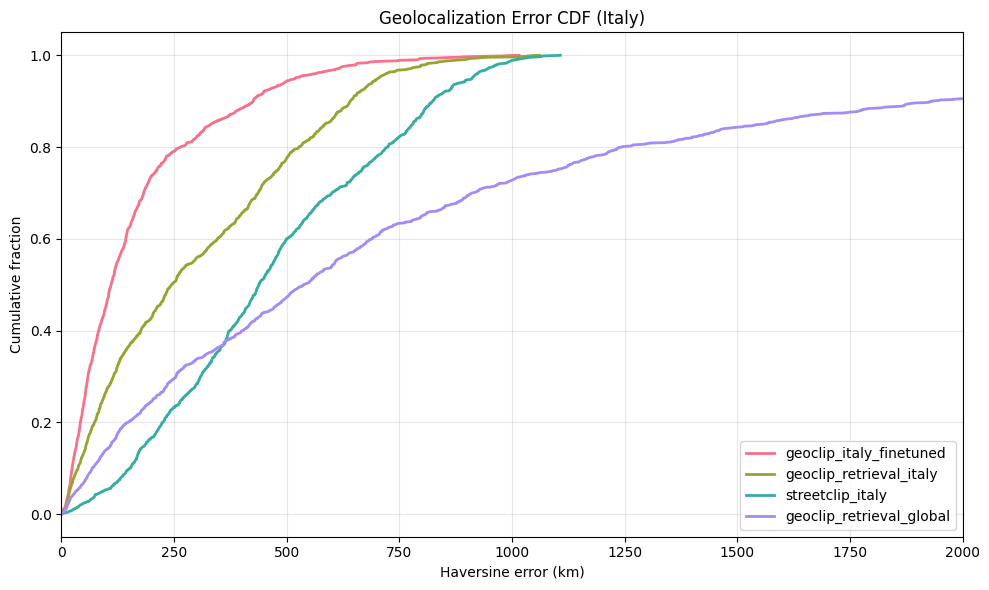

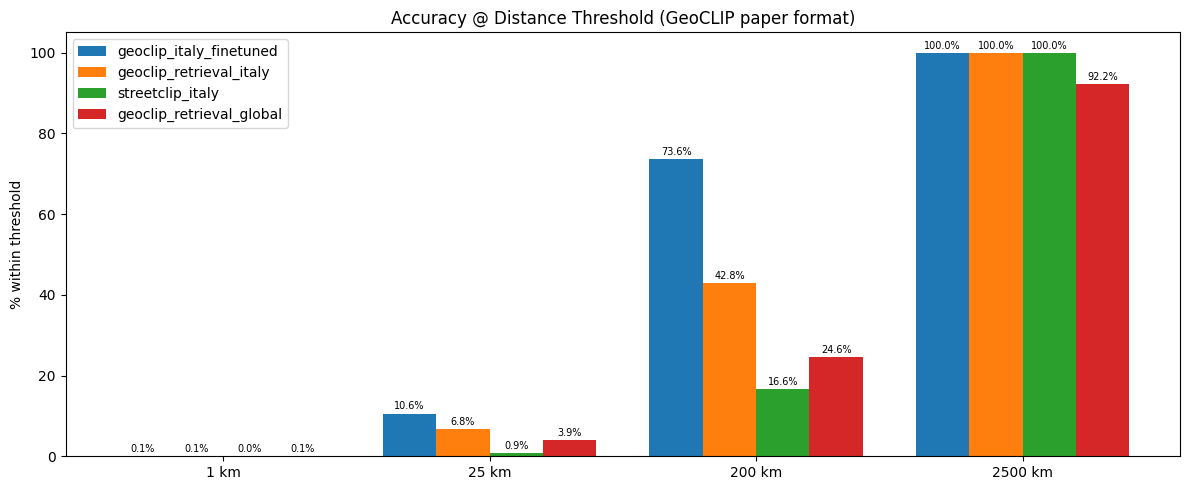

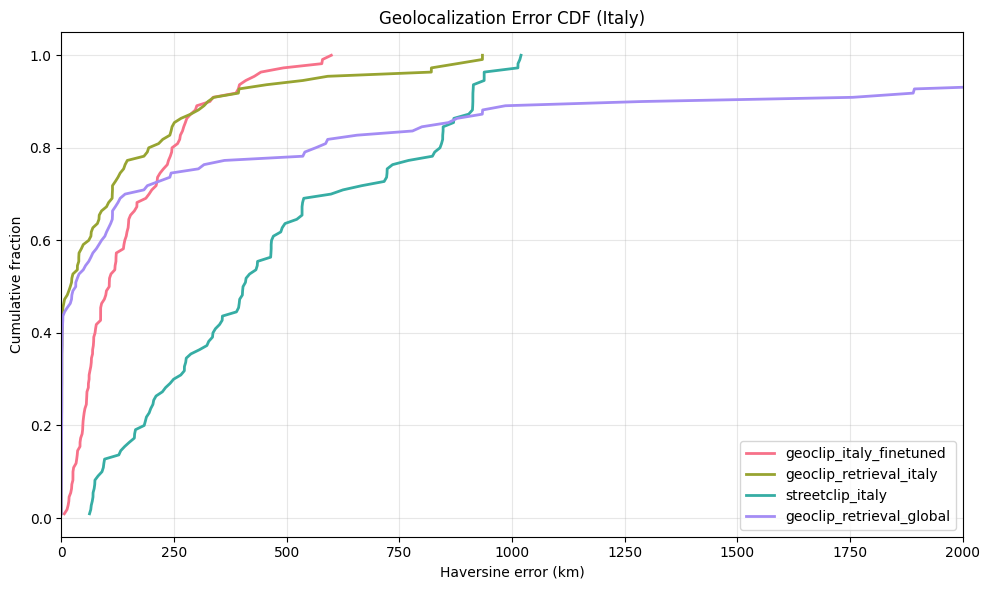

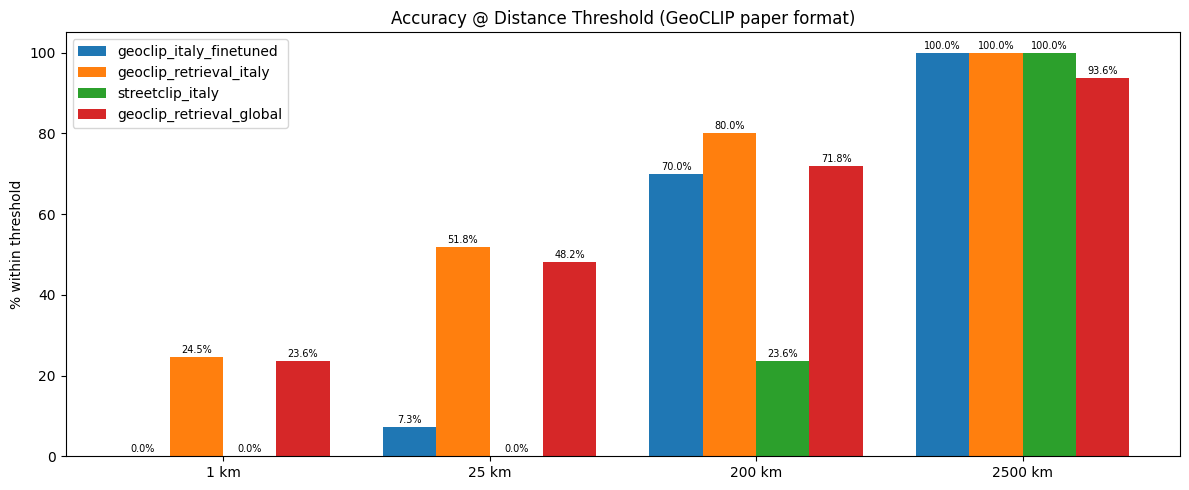

In [6]:
import importlib
import benchmarking.config      as _c
import benchmarking.metrics     as _m
import benchmarking.predictors  as _p
import benchmarking.runner      as _r
import benchmarking.datasets    as _ds
import benchmarking.open_domain as _od
import benchmarking.spatial     as _sp
import benchmarking.visualization as _viz
import benchmarking.sweep       as _sw

# Reload so Drive-copied edits take effect without session restart.
for _mod in [_c, _m, _p, _r, _ds, _od, _sp, _viz, _sw]:
    importlib.reload(_mod)

from benchmarking.config     import BENCHMARK_PACKAGE_VERSION
from benchmarking.predictors import PREDICTORS_VERSION
from benchmarking.runner     import run_benchmark

print(f"Package version : {BENCHMARK_PACKAGE_VERSION}  (need >= 7)")
print(f"Predictors ver  : {PREDICTORS_VERSION}  (need >= 5)")
print("-" * 60)

results = run_benchmark(cfg)

print("\n" + "=" * 60)
print("Inference complete.")
print(f"Datasets evaluated: {list(results.keys())}")

## Section 3 — Metrics

Cells below display:
- **Paper-format table** (GeoCLIP NeurIPS 2023, adapted for Italy)
- **Extended Italy thresholds**
- **Per-region breakdown** (Nord / Centro / Sud/Isole)

In [7]:
import pandas as pd
import numpy as np
from IPython.display import display
from benchmarking.metrics import compute_metrics

# GeoCLIP paper (NeurIPS 2023): acc @ 1 / 25 / 200 / 2500 km.
# Italy adaptation:
#   - 2500 km DROPPED: trivially ~100 % within Italy (max span ~1,200 km)
#   - 100 km ADDED   : meaningful sub-national threshold
_ITALY_PAPER_THRESHOLDS = (1, 25, 100, 200)

print("GeoCLIP-paper-format comparison (Italy-adapted)")
print("  Thresholds: 1 km (street) | 25 km (city) | 100 km (region) | 200 km (wide-region)")
print("  Note: 2500 km country threshold omitted — trivially ~100 % within Italy.\n")

for dataset_name, dataset_results in results.items():
    print(f"{'='*65}  Dataset: {dataset_name.upper()}  {'='*10}")
    rows = []
    for model_name, df in dataset_results.items():
        m = compute_metrics(df, thresholds_km=_ITALY_PAPER_THRESHOLDS)
        rows.append({
            "model"       : model_name,
            "n"           : m.n,
            "mean_km"     : round(m.mean_km, 1)    if m.n else None,
            "median_km"   : round(m.median_km, 1)  if m.n else None,
            "acc@1km %"   : round(m.accuracy_at_km[1],   1) if m.n else 0.0,
            "acc@25km %"  : round(m.accuracy_at_km[25],  1) if m.n else 0.0,
            "acc@100km %" : round(m.accuracy_at_km[100], 1) if m.n else 0.0,
            "acc@200km %" : round(m.accuracy_at_km[200], 1) if m.n else 0.0,
        })
    display(pd.DataFrame(rows))

GeoCLIP-paper-format comparison (Italy-adapted)
  Thresholds: 1 km (street) | 25 km (city) | 100 km (region) | 200 km (wide-region)
  Note: 2500 km country threshold omitted — trivially ~100 % within Italy.

=================================================================  Dataset: OSV5M  ==========


,model,n,mean_km,median_km,acc@1km %,acc@25km %,acc@100km %,acc@200km %
0,geoclip_italy_finetuned,1397,168.0,110.8,0.1,10.6,45.7,73.6
1,geoclip_retrieval_italy,1397,301.7,245.2,0.1,6.8,26.8,42.8
2,streetclip_italy,1397,467.9,438.8,0.0,0.9,5.3,16.6
3,geoclip_retrieval_global,1397,1290.5,538.3,0.1,3.9,14.0,24.6


=================================================================  Dataset: IM2GPS  ==========


,model,n,mean_km,median_km,acc@1km %,acc@25km %,acc@100km %,acc@200km %
0,geoclip_italy_finetuned,110,152.3,106.5,0.0,7.3,48.2,70.0
1,geoclip_retrieval_italy,110,119.3,21.4,24.5,51.8,66.4,80.0
2,streetclip_italy,110,464.1,406.0,0.0,0.0,12.7,23.6
3,geoclip_retrieval_global,110,762.4,32.1,23.6,48.2,60.9,71.8


In [8]:
from benchmarking.metrics import compute_metrics
from benchmarking.config  import ACCURACY_THRESHOLDS_KM

print("Extended Italy thresholds:", ACCURACY_THRESHOLDS_KM, "km\n")

for dataset_name, dataset_results in results.items():
    print(f"{'='*60}  {dataset_name.upper()}")
    for model_name, df in dataset_results.items():
        m = compute_metrics(df, thresholds_km=ACCURACY_THRESHOLDS_KM)
        m.pretty_print(model_name)

Extended Italy thresholds: (1, 10, 25, 50, 100, 200, 500, 2500) km

============================================================  OSV5M

  geoclip_italy_finetuned
    N            : 1,397
    Mean error   : 168.04 km
    Median error : 110.82 km
    90th pct     : 425.48 km
    --- Accuracy @ threshold ---
    Within     1 km : 0.1%
    Within    10 km : 2.1%
    Within    25 km : 10.6%
    Within    50 km : 24.2%
    Within   100 km : 45.7%
    Within   200 km : 73.6%
    Within   500 km : 94.3%
    Within  2500 km : 100.0%

  geoclip_retrieval_italy
    N            : 1,397
    Mean error   : 301.69 km
    Median error : 245.22 km
    90th pct     : 641.31 km
    --- Accuracy @ threshold ---
    Within     1 km : 0.1%
    Within    10 km : 1.4%
    Within    25 km : 6.8%
    Within    50 km : 13.3%
    Within   100 km : 26.8%
    Within   200 km : 42.8%
    Within   500 km : 77.5%
    Within  2500 km : 100.0%

  streetclip_italy
    N            : 1,397
    Mean error   : 467.95 km
 

In [9]:
import numpy as np
import pandas as pd
from IPython.display import display
from benchmarking.metrics import compute_errors_km


def _macro_region(lat: float) -> str:
    if lat > 44.0:   return "Nord"
    if lat > 41.5:   return "Centro"
    return "Sud/Isole"


print("Per-region breakdown")
print("  Nord       : lat > 44.0  (Lombardia, Piemonte, Veneto, ...)")
print("  Centro     : 41.5 < lat <= 44.0  (Toscana, Lazio, Marche, ...)")
print("  Sud/Isole  : lat <= 41.5  (Campania, Sicilia, Sardegna, ...)\n")

for dataset_name, dataset_results in results.items():
    print(f"{'='*70}  {dataset_name.upper()}")
    for model_name, df in dataset_results.items():
        if df.empty:
            print(f"  {model_name}: no predictions")
            continue
        work = compute_errors_km(df)
        if work.empty:
            print(f"  {model_name}: no valid predictions")
            continue
        work = work.copy()
        work["region"] = work["lat_true"].map(_macro_region)

        rows = []
        for region in ["Nord", "Centro", "Sud/Isole", "ALL"]:
            sub = work if region == "ALL" else work[work["region"] == region]
            if sub.empty:
                continue
            e = sub["error_km"].values
            rows.append({
                "region"     : region,
                "n"          : len(e),
                "mean km"    : round(float(np.mean(e)), 1),
                "median km"  : round(float(np.median(e)), 1),
                "@ 25 km %"  : round(float(np.mean(e <= 25)  * 100), 1),
                "@ 100 km %" : round(float(np.mean(e <= 100) * 100), 1),
                "@ 200 km %" : round(float(np.mean(e <= 200) * 100), 1),
            })

        print(f"\n  {model_name}")
        display(pd.DataFrame(rows))

Per-region breakdown
  Nord       : lat > 44.0  (Lombardia, Piemonte, Veneto, ...)
  Centro     : 41.5 < lat <= 44.0  (Toscana, Lazio, Marche, ...)
  Sud/Isole  : lat <= 41.5  (Campania, Sicilia, Sardegna, ...)

======================================================================  OSV5M

  geoclip_italy_finetuned


,region,n,mean km,median km,@ 25 km %,@ 100 km %,@ 200 km %
0,Nord,343,91.1,71.7,15.2,63.8,92.7
1,Centro,320,109.3,83.1,16.6,54.4,85.9
2,Sud/Isole,734,229.6,159.2,5.9,33.4,59.3
3,ALL,1397,168.0,110.8,10.6,45.7,73.6



  geoclip_retrieval_italy


,region,n,mean km,median km,@ 25 km %,@ 100 km %,@ 200 km %
0,Nord,343,199.9,166.9,7.9,29.7,60.1
1,Centro,320,254.0,233.1,5.3,22.2,39.1
2,Sud/Isole,734,370.0,408.5,6.9,27.4,36.4
3,ALL,1397,301.7,245.2,6.8,26.8,42.8



  streetclip_italy


...

,region,n,mean km,median km,@ 25 km %,@ 100 km %,@ 200 km %
0,Nord,70,134.5,18.4,54.3,64.3,77.1
1,Centro,32,82.2,30.7,46.9,68.8,87.5
2,Sud/Isole,8,134.8,26.1,50.0,75.0,75.0
3,ALL,110,119.3,21.4,51.8,66.4,80.0



  streetclip_italy


,region,n,mean km,median km,@ 25 km %,@ 100 km %,@ 200 km %
0,Nord,70,523.9,422.1,0.0,12.9,22.9
1,Centro,32,352.1,376.7,0.0,12.5,28.1
2,Sud/Isole,8,389.2,406.2,0.0,12.5,12.5
3,ALL,110,464.1,406.0,0.0,12.7,23.6



  geoclip_retrieval_global


,region,n,mean km,median km,@ 25 km %,@ 100 km %,@ 200 km %
0,Nord,70,1057.7,36.1,50.0,58.6,70.0
1,Centro,32,189.1,30.7,46.9,65.6,78.1
2,Sud/Isole,8,471.4,32.1,37.5,62.5,62.5
3,ALL,110,762.4,32.1,48.2,60.9,71.8


In [10]:
import pandas as pd
from IPython.display import display

# ── Reference numbers from GeoCLIP paper (NeurIPS 2023) ──────────────────────
# Source: Table 1, "Geolocation Estimation" section, Im2GPS3k dataset.
# These are GLOBAL (worldwide) numbers, NOT Italy-constrained.
# They are shown here for context only — direct numerical comparison with our
# Italy-only results is not valid.
#
# Our setup differs in:
#   - geography: Italy-only (bbox 35.4–47.2°N, 6.6–18.8°E)
#   - dataset: OSV5M Italy (1,397 images) vs Im2GPS3k (2,997 images)
#   - GeoCLIP: we use Italy-constrained gallery (no country-scale retrieval)
#
# Models in the paper we CAN run:
#   - GeoCLIP (Italy-constrained)     ← "geoclip_retrieval_italy" above
#   - GeoEstimation / ISNs [12]       ← enable with INCLUDE_GEOESTIMATION = True
#
# Models we CANNOT run (no public pretrained weights):
#   - PlaNet [16]: Google-internal inception net, trained on 100M geotagged images
#   - CPlaNet [6]: hierarchical subdivision of PlaNet cells
#   - Translocator [14]: transformers-based, weights not released
#   - GeoDecoder [5]: CLIP + GPS decoder, weights not released

_paper_ref = pd.DataFrame([
    # acc columns = Im2GPS3k accuracy @ 1/25/200/2500 km (paper Table 1)
    {"model": "PlaNet [16]",      "available": "No",  "acc@1km": 8.46,  "acc@25km": 24.69, "acc@200km": 37.57, "acc@2500km": 55.53, "note": "Google-internal, no public weights"},
    {"model": "CPlaNet [6]",      "available": "No",  "acc@1km": 10.45, "acc@25km": 27.75, "acc@200km": 42.55, "acc@2500km": 61.55, "note": "Hierarchical subdivision of PlaNet"},
    {"model": "ISNs [12]",        "available": "Yes", "acc@1km": 12.55, "acc@25km": 27.75, "acc@200km": 40.63, "acc@2500km": 63.54, "note": "= GeoEstimation (TIBHannover); enable above"},
    {"model": "Translocator [14]","available": "No",  "acc@1km": 12.60, "acc@25km": 29.67, "acc@200km": 43.10, "acc@2500km": 65.62, "note": "Transformer-based, weights not released"},
    {"model": "GeoDecoder [5]",   "available": "No",  "acc@1km": 12.19, "acc@25km": 27.97, "acc@200km": 40.89, "acc@2500km": 63.62, "note": "CLIP + GPS decoder, weights not released"},
    {"model": "GeoCLIP (global)", "available": "Yes", "acc@1km": 14.11, "acc@25km": 34.47, "acc@200km": 50.65, "acc@2500km": 83.82, "note": "Full gallery; Italy-constrained is our base model"},
])

print("Reference: GeoCLIP paper Table 1 — Im2GPS3k, GLOBAL (worldwide) evaluation")
print("  ⚠  These numbers are NOT comparable to our Italy-only results.")
print("  They are included to show where each model sits on the worldwide benchmark.\n")
display(_paper_ref.set_index("model"))

Reference: GeoCLIP paper Table 1 — Im2GPS3k, GLOBAL (worldwide) evaluation
  ⚠  These numbers are NOT comparable to our Italy-only results.
  They are included to show where each model sits on the worldwide benchmark.



,available,acc@1km,acc@25km,acc@200km,acc@2500km,note
model,,,,,,
PlaNet [16],No,8.46,24.69,37.57,55.53,"Google-internal, no public weights"
CPlaNet [6],No,10.45,27.75,42.55,61.55,Hierarchical subdivision of PlaNet
ISNs [12],Yes,12.55,27.75,40.63,63.54,= GeoEstimation (TIBHannover); enable above
Translocator [14],No,12.60,29.67,43.10,65.62,"Transformer-based, weights not released"
GeoDecoder [5],No,12.19,27.97,40.89,63.62,"CLIP + GPS decoder, weights not released"
GeoCLIP (global),Yes,14.11,34.47,50.65,83.82,Full gallery; Italy-constrained is our base model


## Section 4 — Visualizations

- **Error CDF** — cumulative fraction of predictions within X km
- **Accuracy bars** — GeoCLIP paper thresholds (1/25/100/200 km)
- **Error histogram** — distribution of per-image errors (clipped @ 600 km)
- **Worst-case map** — top-20 largest errors, GT vs predicted positions

Saved CDF: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/osv5m_error_cdf.png


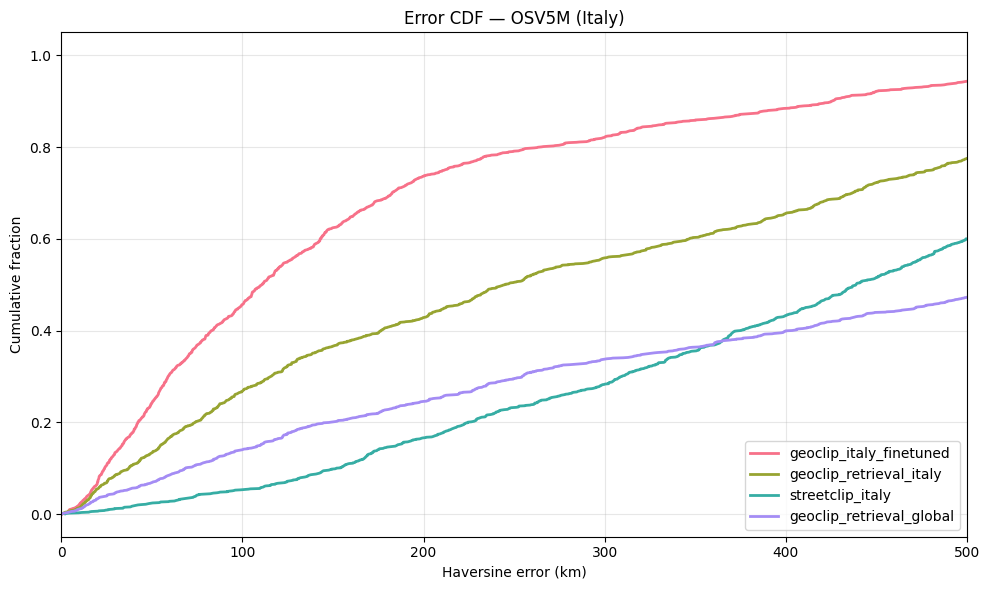

Saved CDF: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/im2gps_error_cdf.png


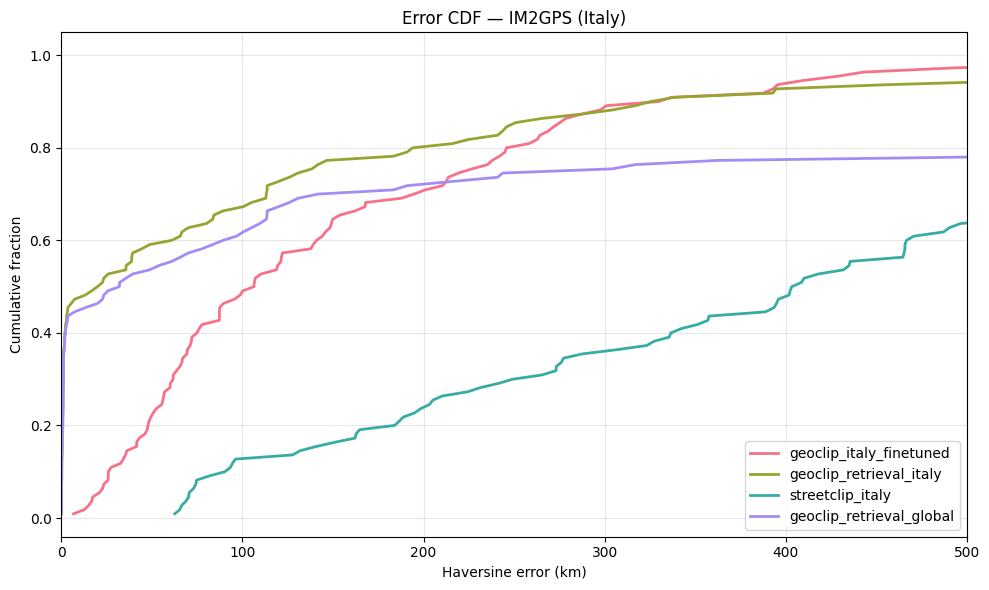

In [11]:
import matplotlib.pyplot as plt
from benchmarking.visualization import plot_error_cdf

for dataset_name, dataset_results in results.items():
    valid = {k: v for k, v in dataset_results.items() if not v.empty}
    if not valid:
        print(f"[{dataset_name}] No valid predictions to plot.")
        continue
    fig = plot_error_cdf(
        valid,
        output_path=f"{cfg.output_dir}/{dataset_name}_error_cdf.png",
        max_km=500.0,
        title=f"Error CDF — {dataset_name.upper()} (Italy)",
    )
    plt.show()

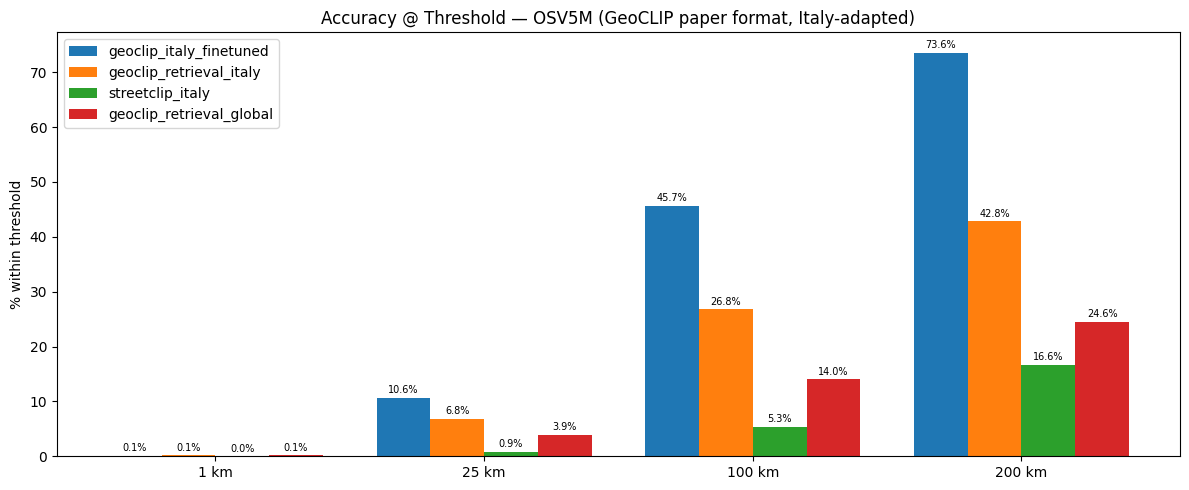

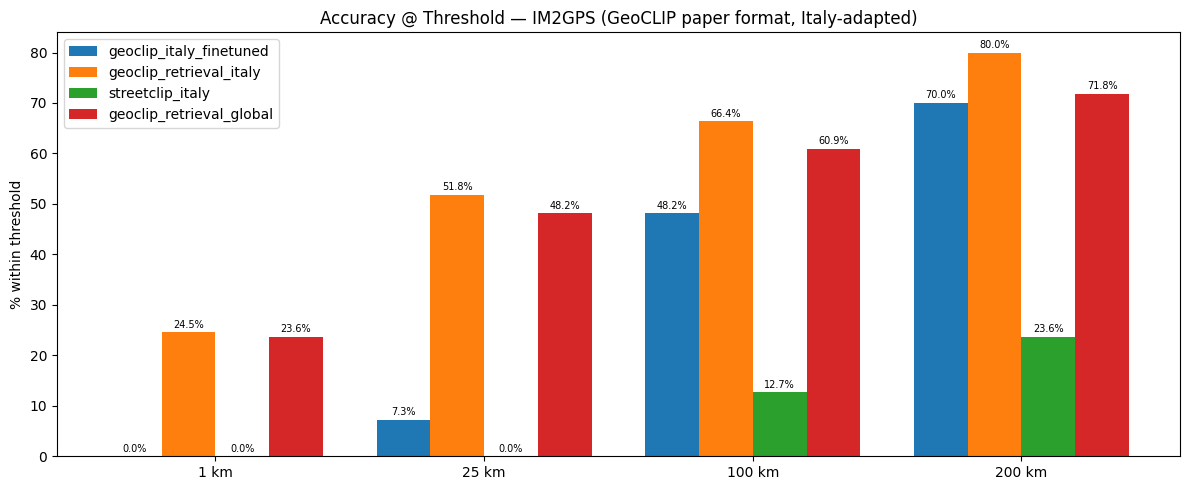

In [12]:
import matplotlib.pyplot as plt
from benchmarking.visualization import plot_accuracy_bars

_ITALY_PAPER_THRESHOLDS = (1, 25, 100, 200)

for dataset_name, dataset_results in results.items():
    valid = {k: v for k, v in dataset_results.items() if not v.empty}
    if not valid:
        continue
    fig = plot_accuracy_bars(
        valid,
        output_path=f"{cfg.output_dir}/{dataset_name}_accuracy_bars.png",
        thresholds_km=_ITALY_PAPER_THRESHOLDS,
        title=f"Accuracy @ Threshold — {dataset_name.upper()} (GeoCLIP paper format, Italy-adapted)",
    )
    plt.show()

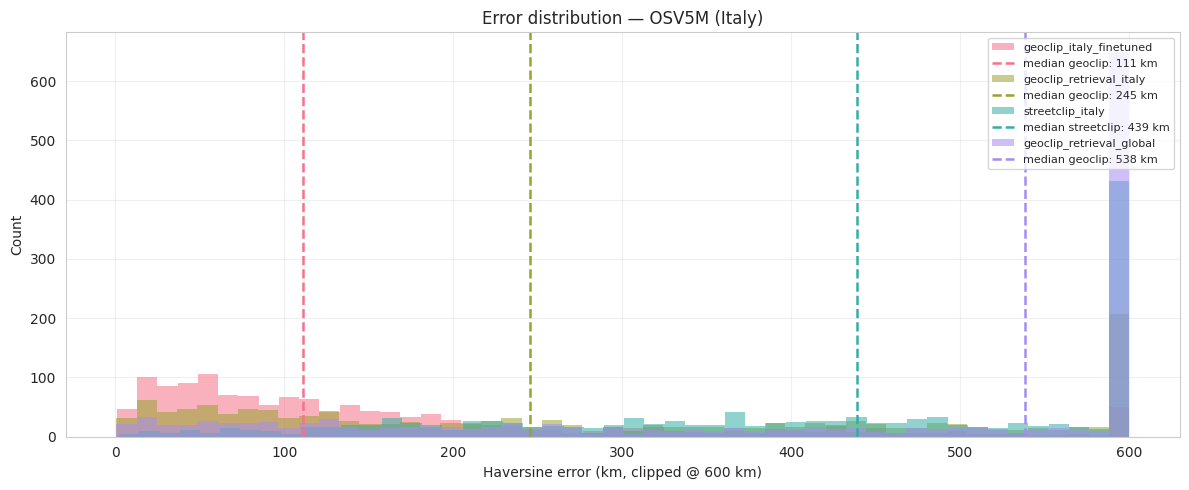

Saved: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/osv5m_error_histogram.png


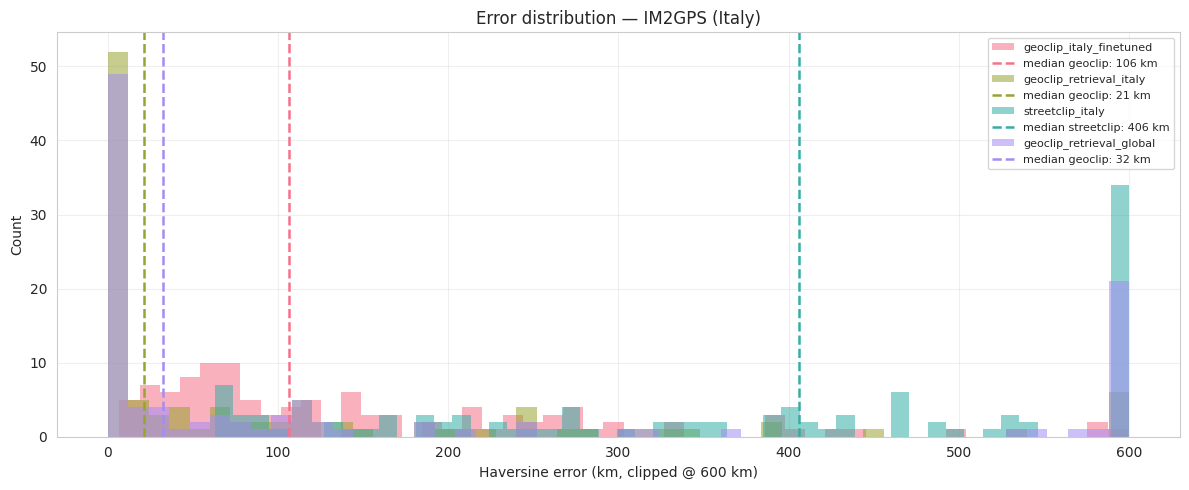

Saved: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/im2gps_error_histogram.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from benchmarking.metrics import compute_errors_km

sns.set_style("whitegrid")
_CLIP_KM = 600  # clip tail for readability; actual errors may exceed this

for dataset_name, dataset_results in results.items():
    valid_items = [(k, v) for k, v in dataset_results.items() if not v.empty]
    if not valid_items:
        continue

    palette = sns.color_palette("husl", n_colors=len(valid_items))
    fig, ax = plt.subplots(figsize=(12, 5))

    for i, (model_name, df) in enumerate(valid_items):
        work = compute_errors_km(df)
        if work.empty:
            continue
        raw_errors = work["error_km"].values
        clipped    = np.clip(raw_errors, 0, _CLIP_KM)
        med        = float(np.median(raw_errors))
        ax.hist(clipped, bins=50, alpha=0.55, color=palette[i],
                label=model_name, edgecolor="none")
        ax.axvline(min(med, _CLIP_KM), color=palette[i], linestyle="--", linewidth=1.8,
                   label=f"median {model_name.split('_')[0]}: {med:.0f} km")

    ax.set_xlabel(f"Haversine error (km, clipped @ {_CLIP_KM} km)")
    ax.set_ylabel("Count")
    ax.set_title(f"Error distribution — {dataset_name.upper()} (Italy)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    out = f"{cfg.output_dir}/{dataset_name}_error_histogram.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

/content/drive/MyDrive/Vision_Project_2026/benchmarking/visualization.py:108: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(df["lon_pred"], df["lat_pred"], c=color, s=10, alpha=0.5, label="Predicted")
/content/drive/MyDrive/Vision_Project_2026/benchmarking/visualization.py:108: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(df["lon_pred"], df["lat_pred"], c=color, s=10, alpha=0.5, label="Predicted")
/con

Saved scatter: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/osv5m_scatter_by_model.png


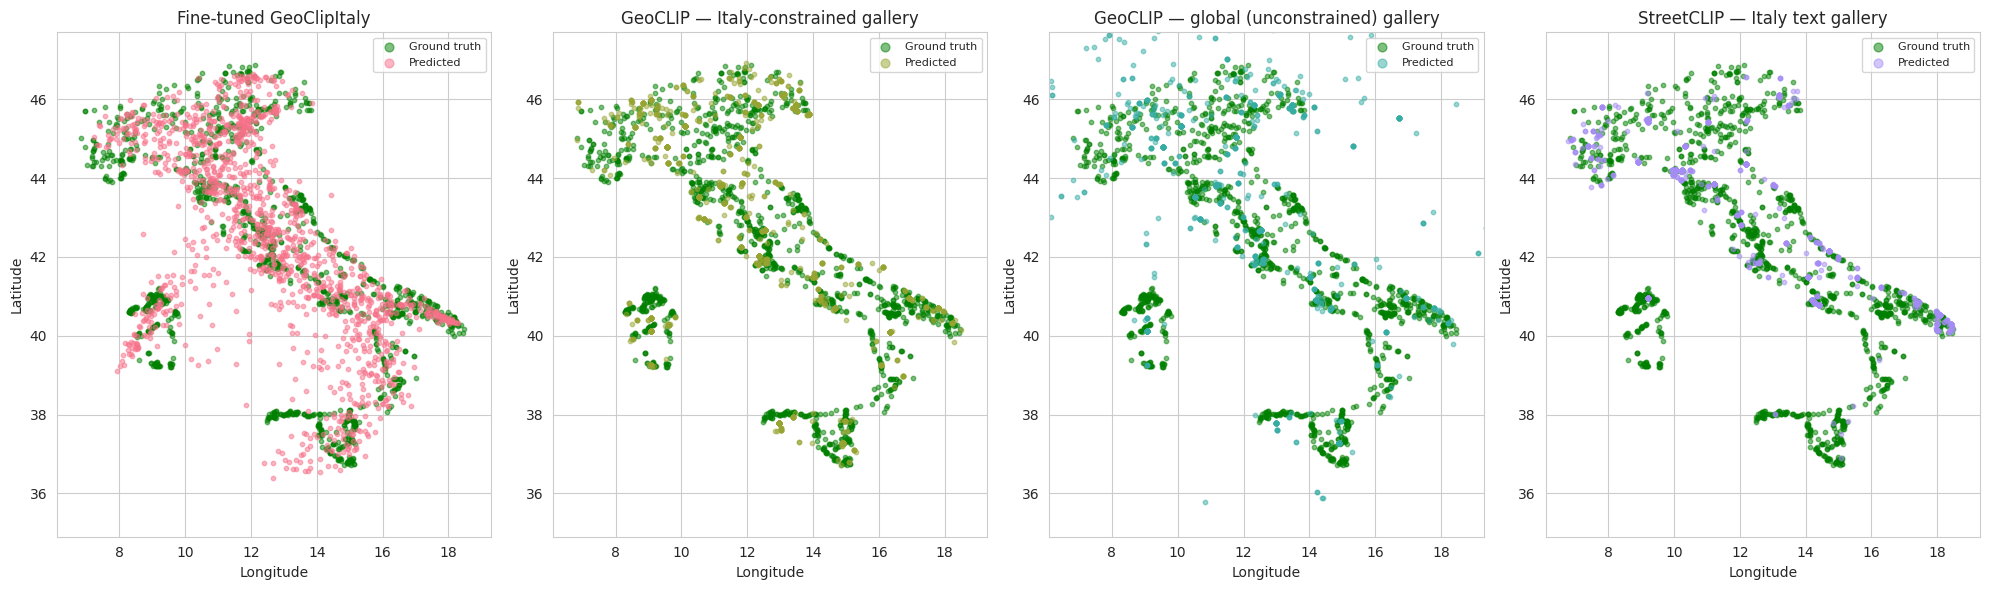

Saved confusion matrix: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/osv5m_region_confusion.png


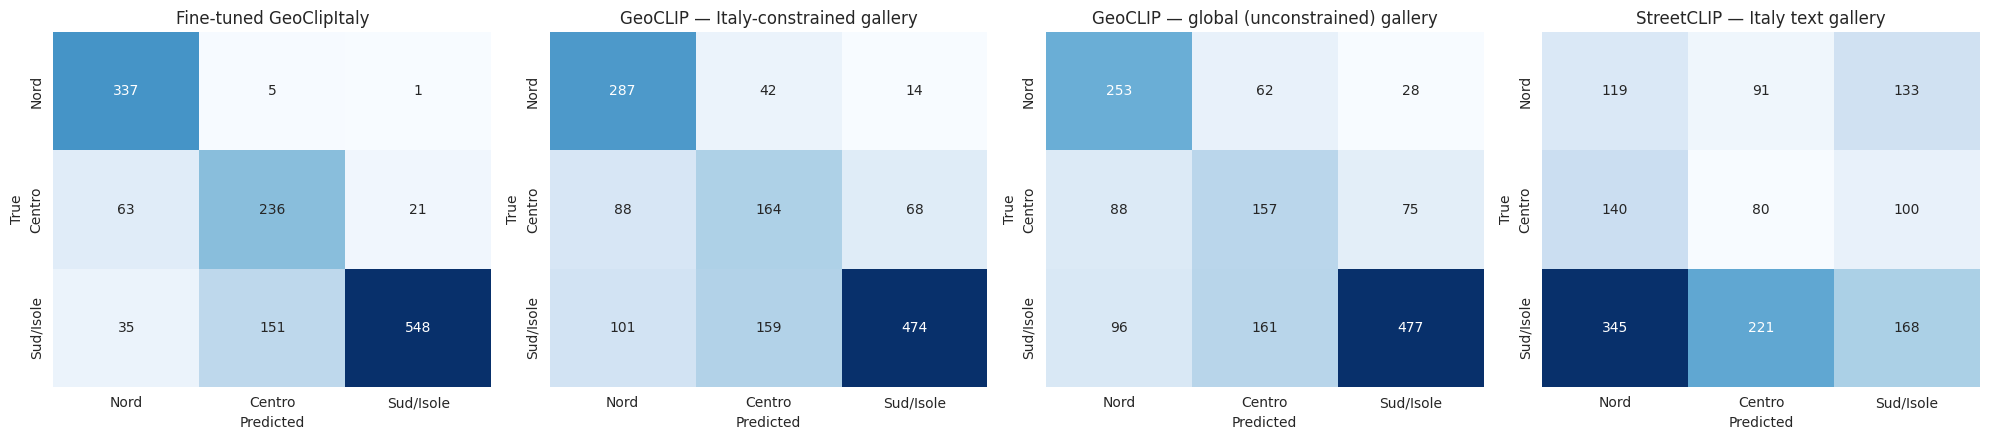

/content/drive/MyDrive/Vision_Project_2026/benchmarking/visualization.py:108: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(df["lon_pred"], df["lat_pred"], c=color, s=10, alpha=0.5, label="Predicted")
/content/drive/MyDrive/Vision_Project_2026/benchmarking/visualization.py:108: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(df["lon_pred"], df["lat_pred"], c=color, s=10, alpha=0.5, label="Predicted")
/con

Saved scatter: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/im2gps_scatter_by_model.png


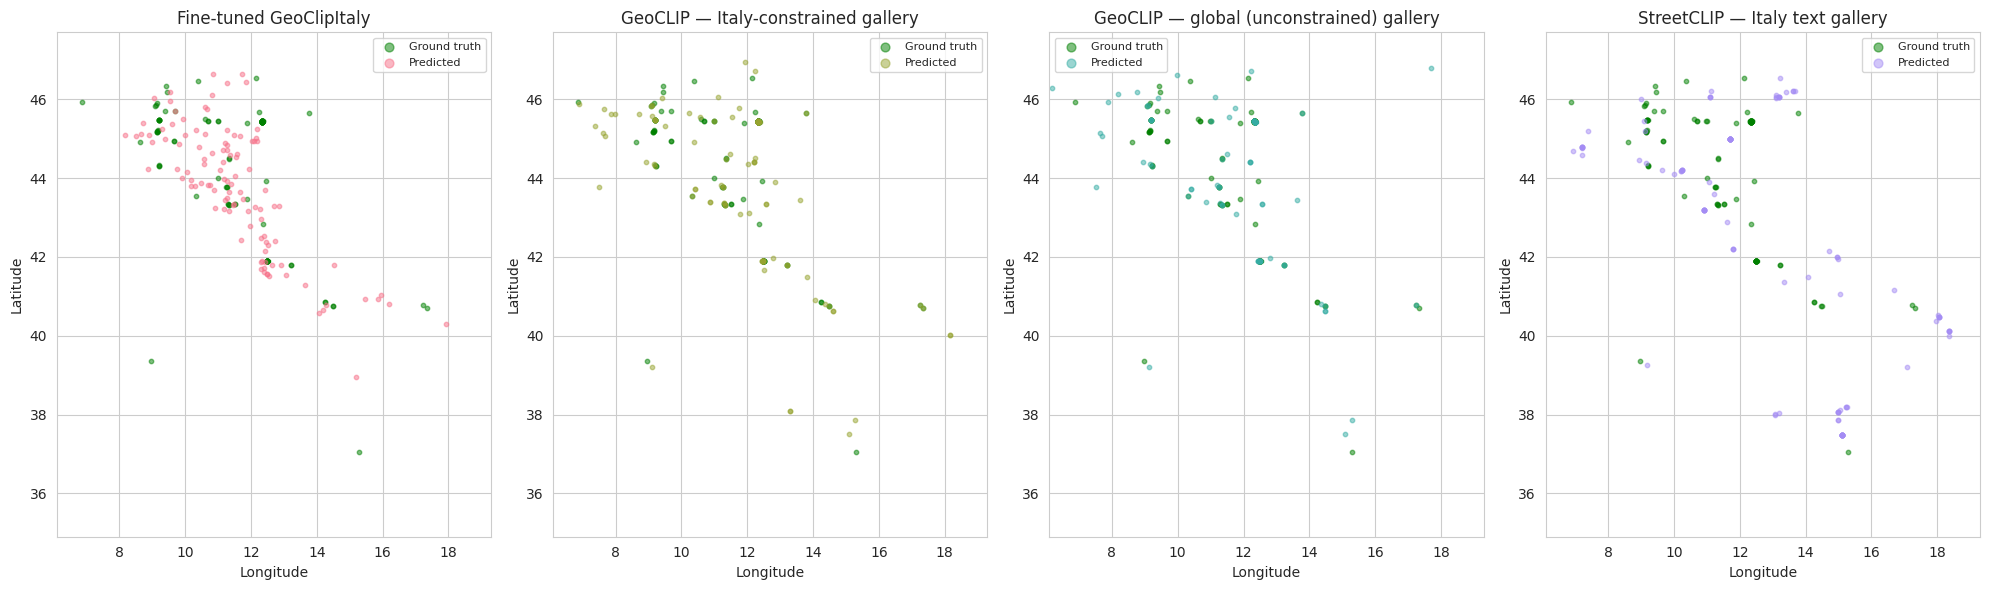

Saved confusion matrix: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/im2gps_region_confusion.png


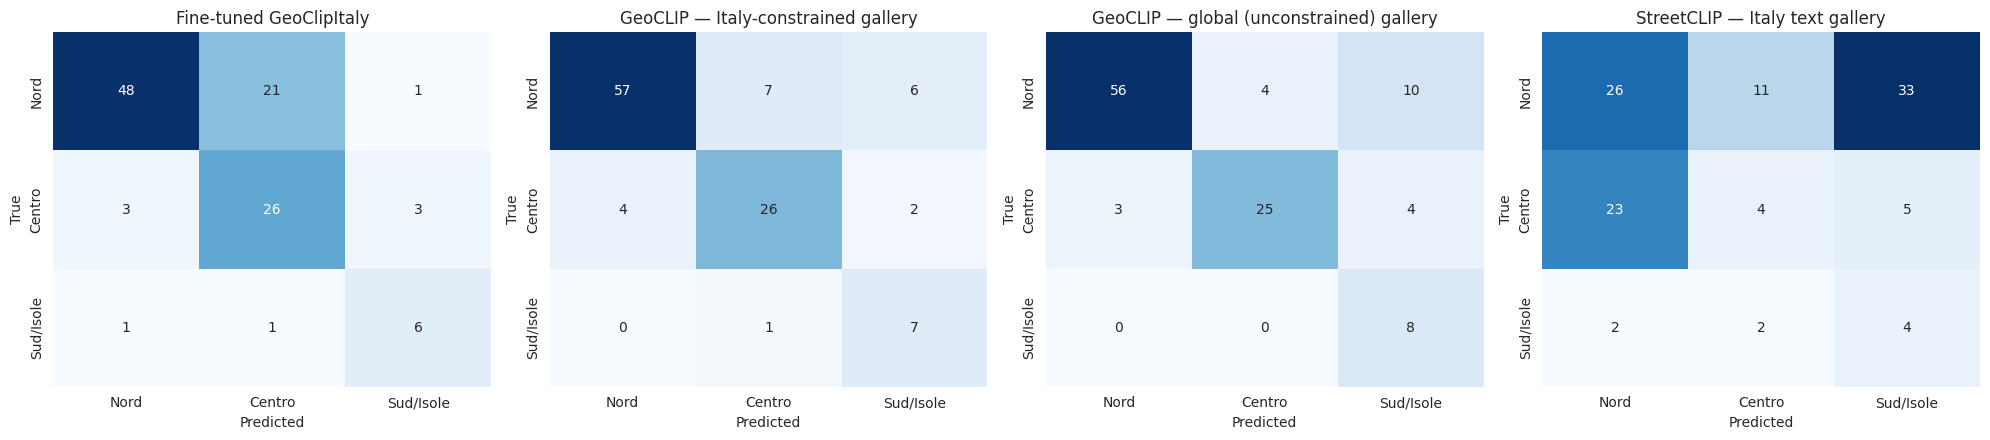

In [14]:
import matplotlib.pyplot as plt
from benchmarking.visualization import plot_prediction_scatter, plot_region_confusion

# Every model key this pipeline can produce, mapped to the exact caption its panel must
# carry. Passed explicitly to plot_prediction_scatter/plot_region_confusion (which refuse
# to plot without a label) so a reader can never mistake an unconstrained-gallery baseline
# for the Italy-constrained one, or vice versa.
_MODEL_LABELS = {
    "geoclip_italy_finetuned": "Fine-tuned GeoClipItaly",
    "geoclip_retrieval_italy": "GeoCLIP — Italy-constrained gallery",
    "geoclip_retrieval_global": "GeoCLIP — global (unconstrained) gallery",
    "streetclip_italy": "StreetCLIP — Italy text gallery",
    "geo_estimation_italy": "GeoEstimation (ISNs) — Italy-constrained",
}

for dataset_name, dataset_results in results.items():
    present = [k for k in _MODEL_LABELS if k in dataset_results and not dataset_results[k].empty]
    if not present:
        continue
    if "geoclip_retrieval_global" not in present:
        print(
            f"[{dataset_name}] NOTE: geoclip_retrieval_global not in results — set "
            "INCLUDE_GLOBAL_GEOCLIP = True in Cell 02 to include the unconstrained-gallery "
            "baseline in this comparison (needed for the paper's 3-way scatter figure)."
        )

    fig = plot_prediction_scatter(
        dataset_results, labels=_MODEL_LABELS, keys=present,
        output_path=f"{cfg.output_dir}/{dataset_name}_scatter_by_model.png",
    )
    plt.show()

    fig = plot_region_confusion(
        dataset_results, labels=_MODEL_LABELS, keys=present,
        output_path=f"{cfg.output_dir}/{dataset_name}_region_confusion.png",
    )
    plt.show()

In [15]:
from IPython.display import HTML, display
from benchmarking.visualization import plot_worst_cases_map
from benchmarking.metrics       import compute_errors_km

for dataset_name, dataset_results in results.items():
    ft_name   = "geoclip_italy_finetuned"
    base_name = "geoclip_retrieval_italy"

    if ft_name not in dataset_results or dataset_results[ft_name].empty:
        print(f"[{dataset_name}] Fine-tuned results not found — skipping worst-case map.")
        continue

    ft_df   = dataset_results[ft_name]
    base_df = dataset_results.get(base_name)

    if compute_errors_km(ft_df).empty:
        print(f"[{dataset_name}] No valid fine-tuned predictions — skipping worst-case map.")
        continue

    # Fallback: use first available baseline if Italy-constrained one is missing
    if base_df is None or base_df.empty:
        for name, df in dataset_results.items():
            if name != ft_name and not df.empty:
                base_df  = df
                base_name = name
                break

    map_path = plot_worst_cases_map(
        reference_df=ft_df,
        compare_df=base_df,
        n_worst=20,
        output_path=f"{cfg.output_dir}/{dataset_name}_worst20_map.html",
        reference_label="GeoClipItaly (fine-tuned V3.3)",
        compare_label=f"GeoCLIP retrieval ({base_name.split('_')[-1]})",
    )
    display(HTML(
        f'<b>{dataset_name}</b>: '
        f'<a href="{map_path}" target="_blank">Open worst-case map (top-20 failures)</a>'
    ))

Saved failure map: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/osv5m_worst20_map.html


Saved failure map: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/im2gps_worst20_map.html


## Section 5 — Save & Summary

Saves all prediction CSVs, metrics summaries, and displays all generated artifacts.

Saved metrics summary: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/osv5m_metrics_summary.csv
GeoCLIP paper metrics (osv5m) -> /content/drive/MyDrive/Vision_Project_2026/benchmark_results/osv5m_paper_metrics.csv


,model,mean_km,median_km,acc@1km,acc@25km,acc@200km,acc@2500km,n
0,geoclip_italy_finetuned,168.0,110.8,0.1,10.6,73.6,100.0,1397
1,geoclip_retrieval_italy,301.7,245.2,0.1,6.8,42.8,100.0,1397
2,streetclip_italy,467.9,438.8,0.0,0.9,16.6,100.0,1397
3,geoclip_retrieval_global,1290.5,538.3,0.1,3.9,24.6,92.2,1397


Saved metrics summary: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/im2gps_metrics_summary.csv
GeoCLIP paper metrics (im2gps) -> /content/drive/MyDrive/Vision_Project_2026/benchmark_results/im2gps_paper_metrics.csv


,model,mean_km,median_km,acc@1km,acc@25km,acc@200km,acc@2500km,n
0,geoclip_italy_finetuned,152.3,106.5,0.0,7.3,70.0,100.0,110
1,geoclip_retrieval_italy,119.3,21.4,24.5,51.8,80.0,100.0,110
2,streetclip_italy,464.1,406.0,0.0,0.0,23.6,100.0,110
3,geoclip_retrieval_global,762.4,32.1,23.6,48.2,71.8,93.6,110



All artifacts in: /content/drive/MyDrive/Vision_Project_2026/benchmark_results

--- im2gps_accuracy_bars.png


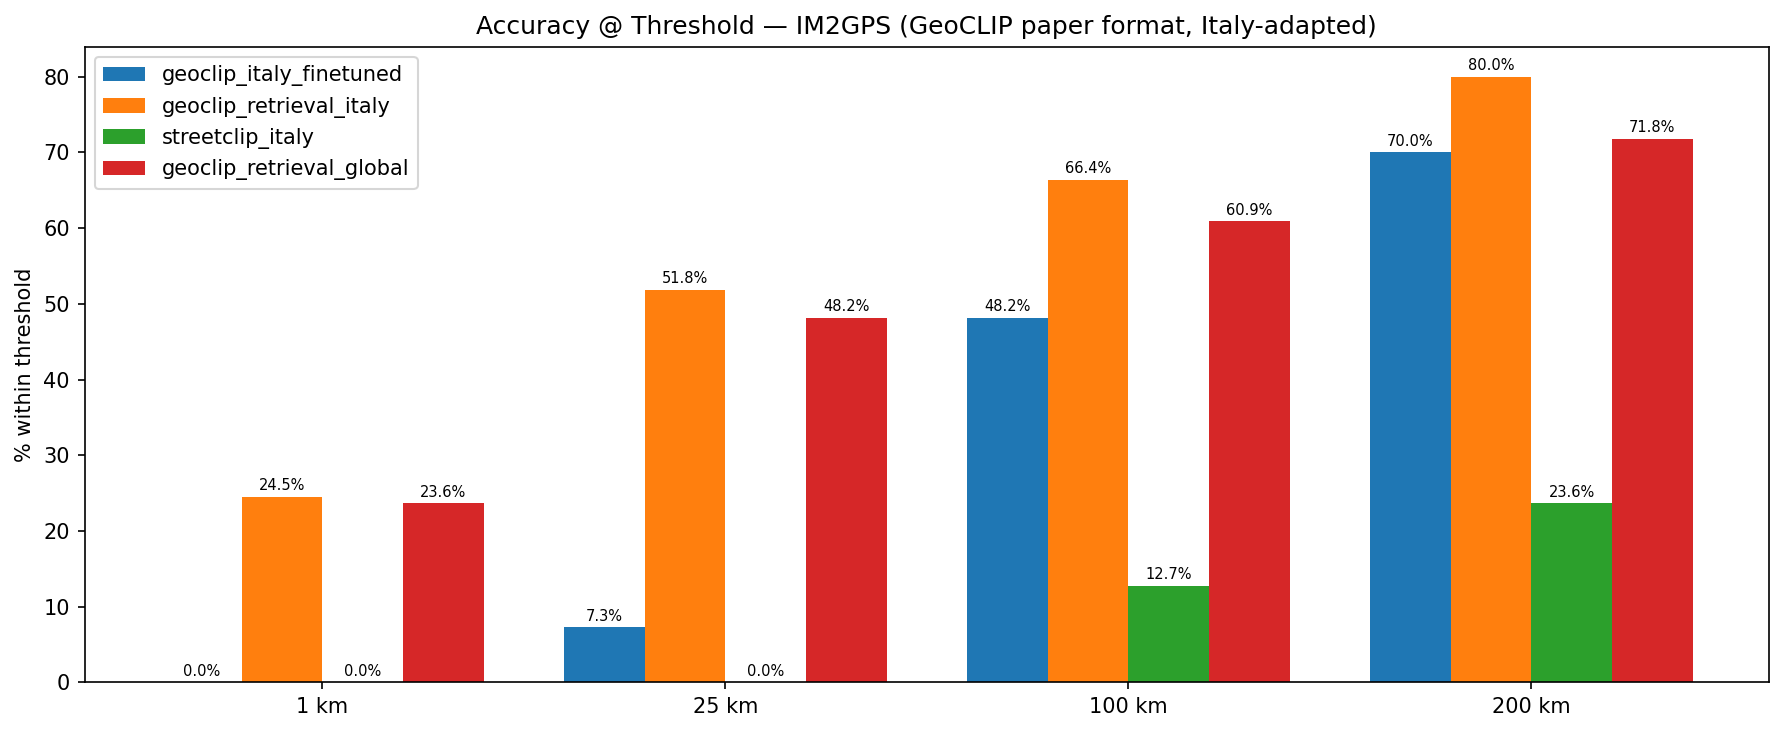


--- im2gps_error_cdf.png


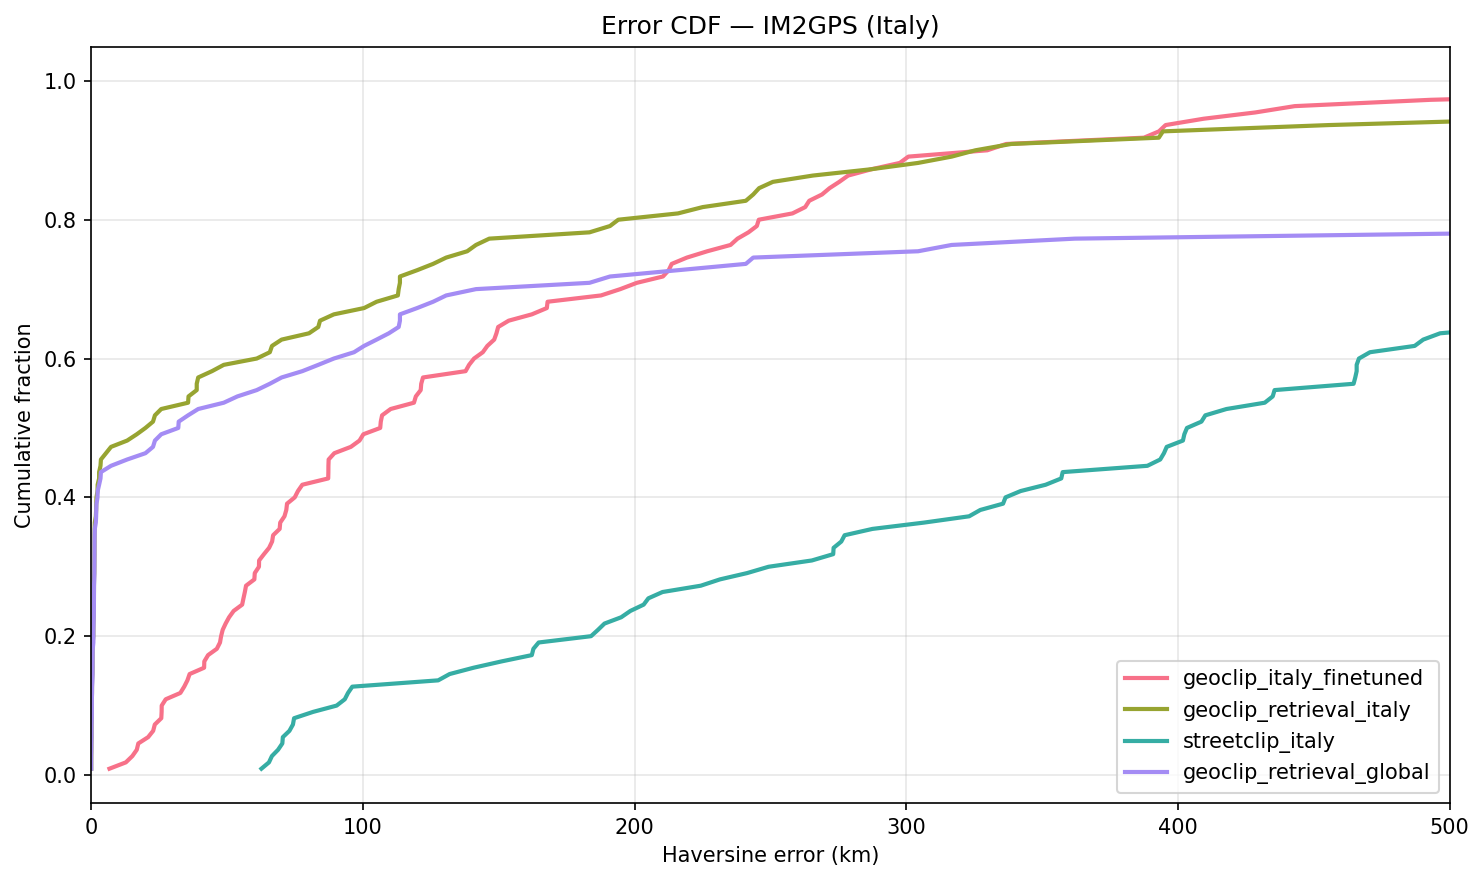


--- im2gps_error_histogram.png


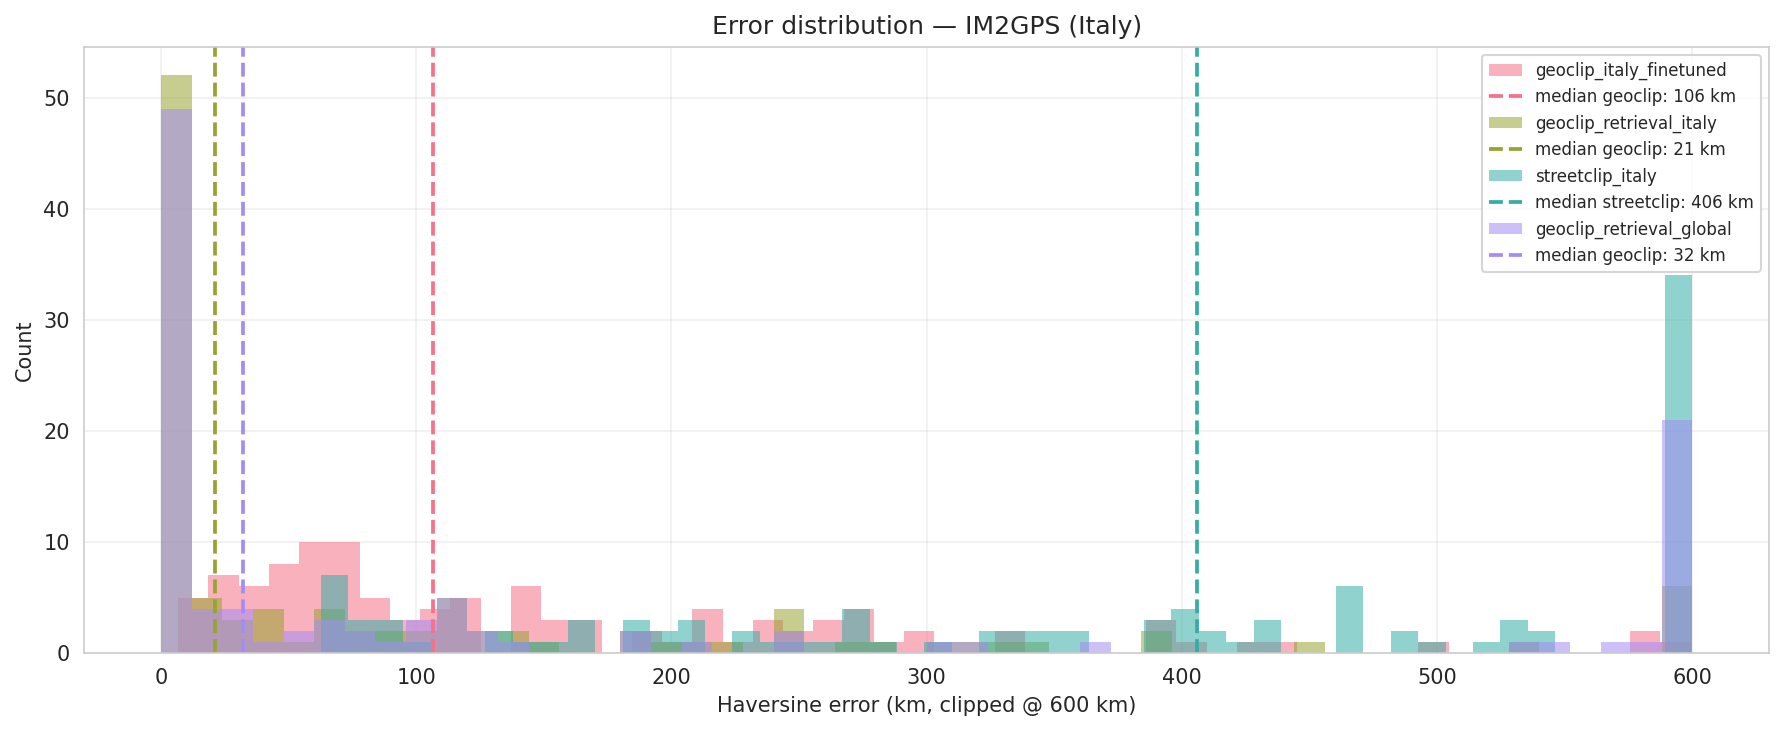


--- im2gps_metrics_summary.csv


,dataset,model,n,mean_km,median_km,p90_km,acc_1km_pct,acc_10km_pct,acc_25km_pct,acc_50km_pct,acc_100km_pct,acc_200km_pct,acc_500km_pct,acc_2500km_pct
0,im2gps,geoclip_italy_finetuned,110,152.258605,106.497758,330.524843,0.000000,0.909091,7.272727,21.818182,48.181818,70.000000,97.272727,100.000000
1,im2gps,geoclip_retrieval_italy,110,119.272092,21.368670,326.769621,24.545455,47.272727,51.818182,59.090909,66.363636,80.000000,93.636364,100.000000
2,im2gps,streetclip_italy,110,464.090129,406.002302,913.400491,0.000000,0.000000,0.000000,0.000000,12.727273,23.636364,63.636364,100.000000
3,im2gps,geoclip_retrieval_global,110,762.359670,32.142982,1334.501132,23.636364,44.545455,48.181818,53.636364,60.909091,71.818182,77.272727,93.636364



--- im2gps_region_confusion.png


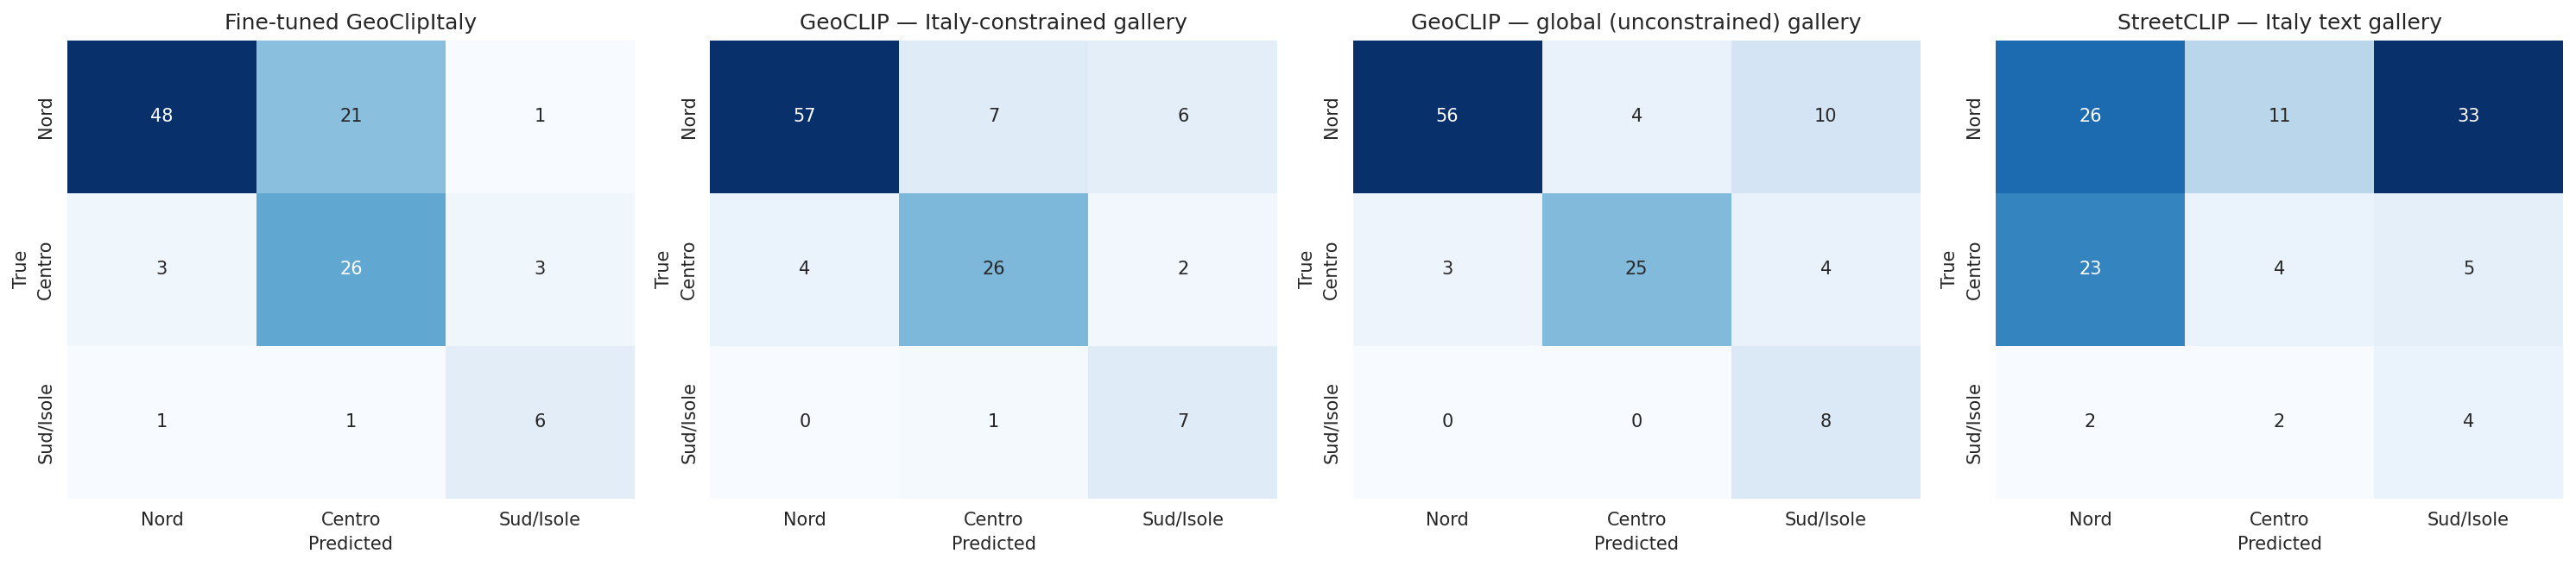


--- im2gps_scatter_by_model.png


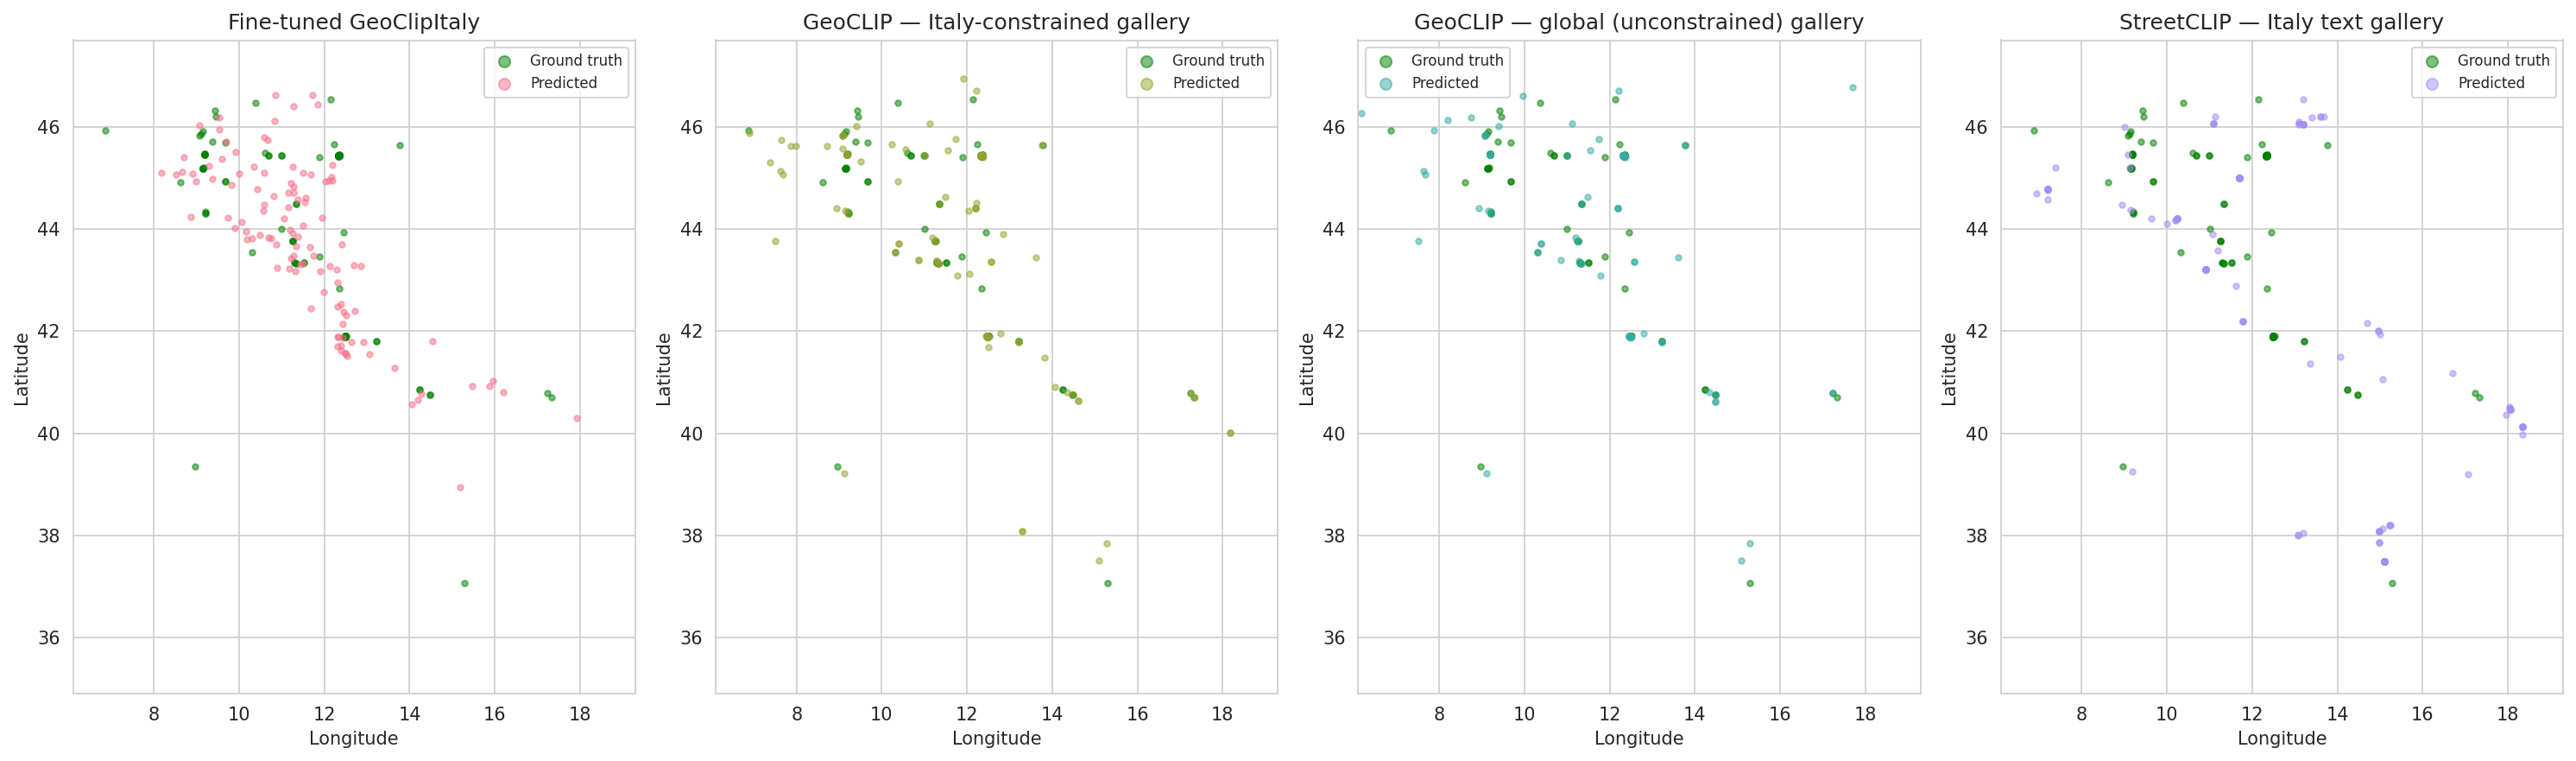


--- osv5m_accuracy_bars.png


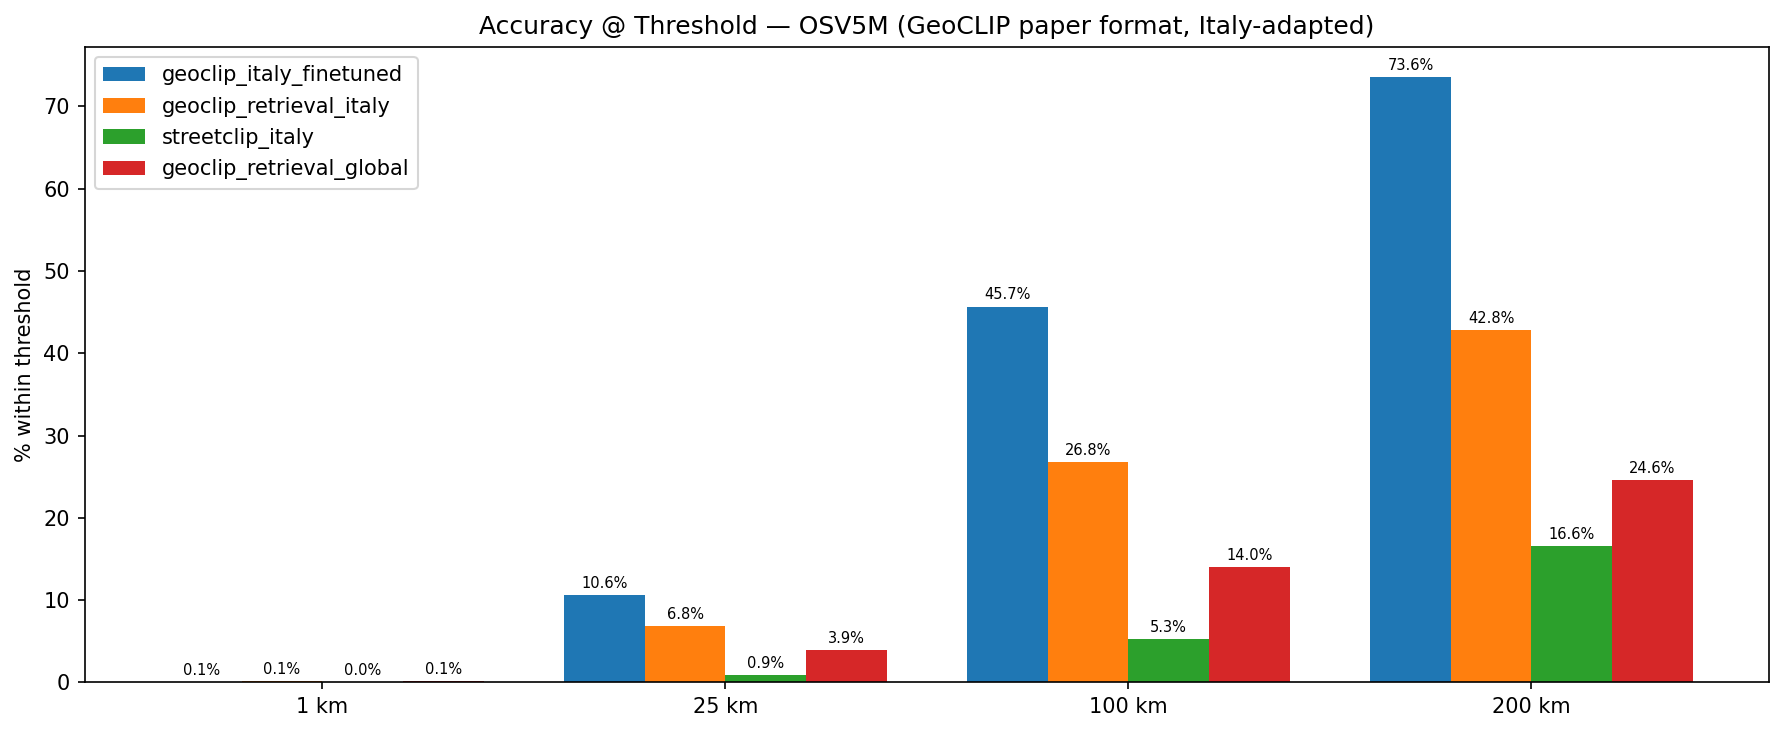


--- osv5m_error_cdf.png


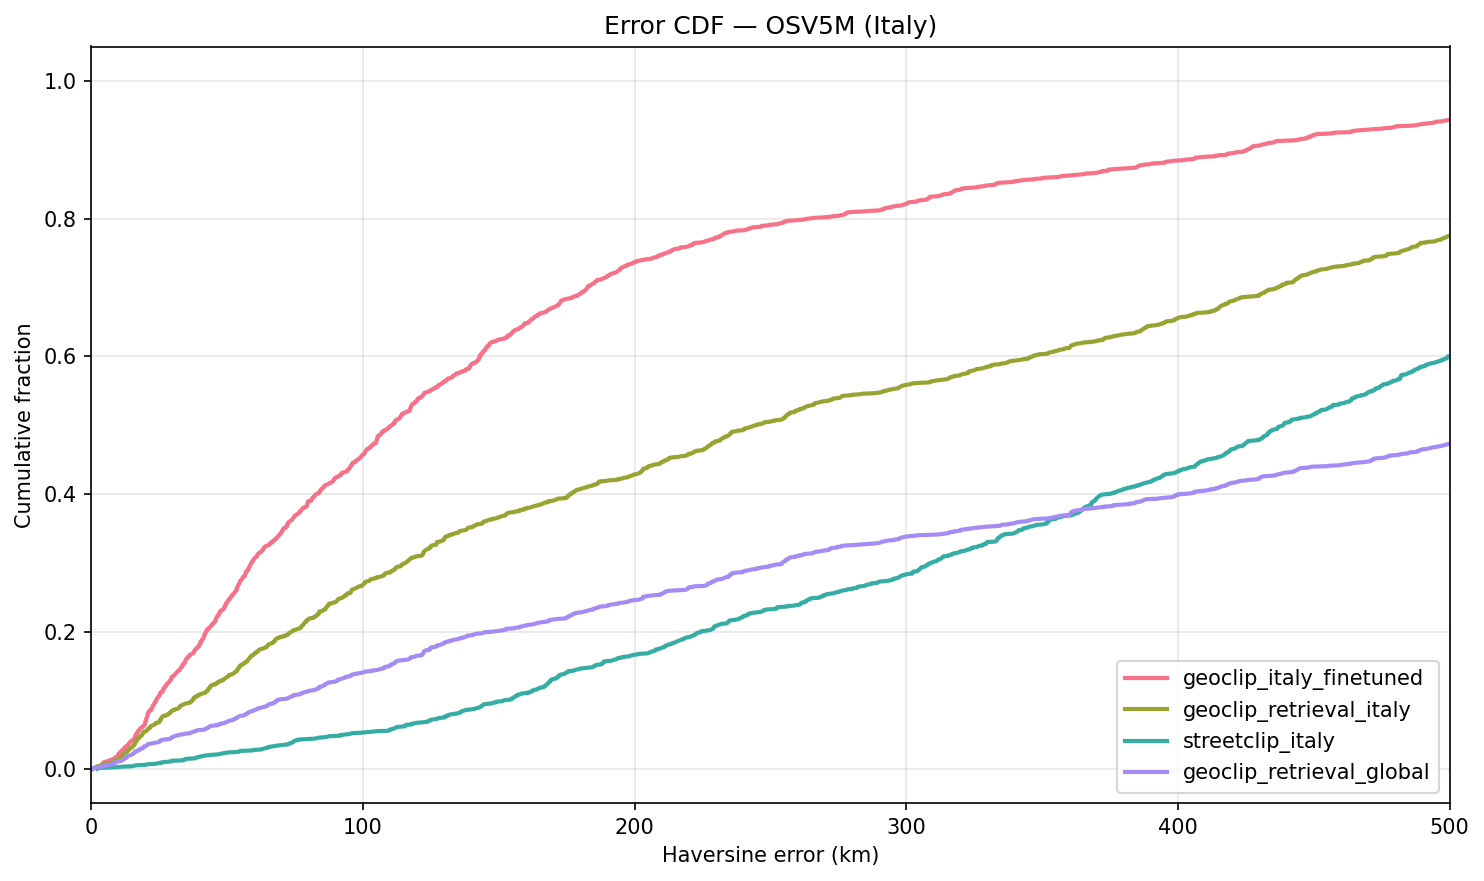


--- osv5m_error_histogram.png


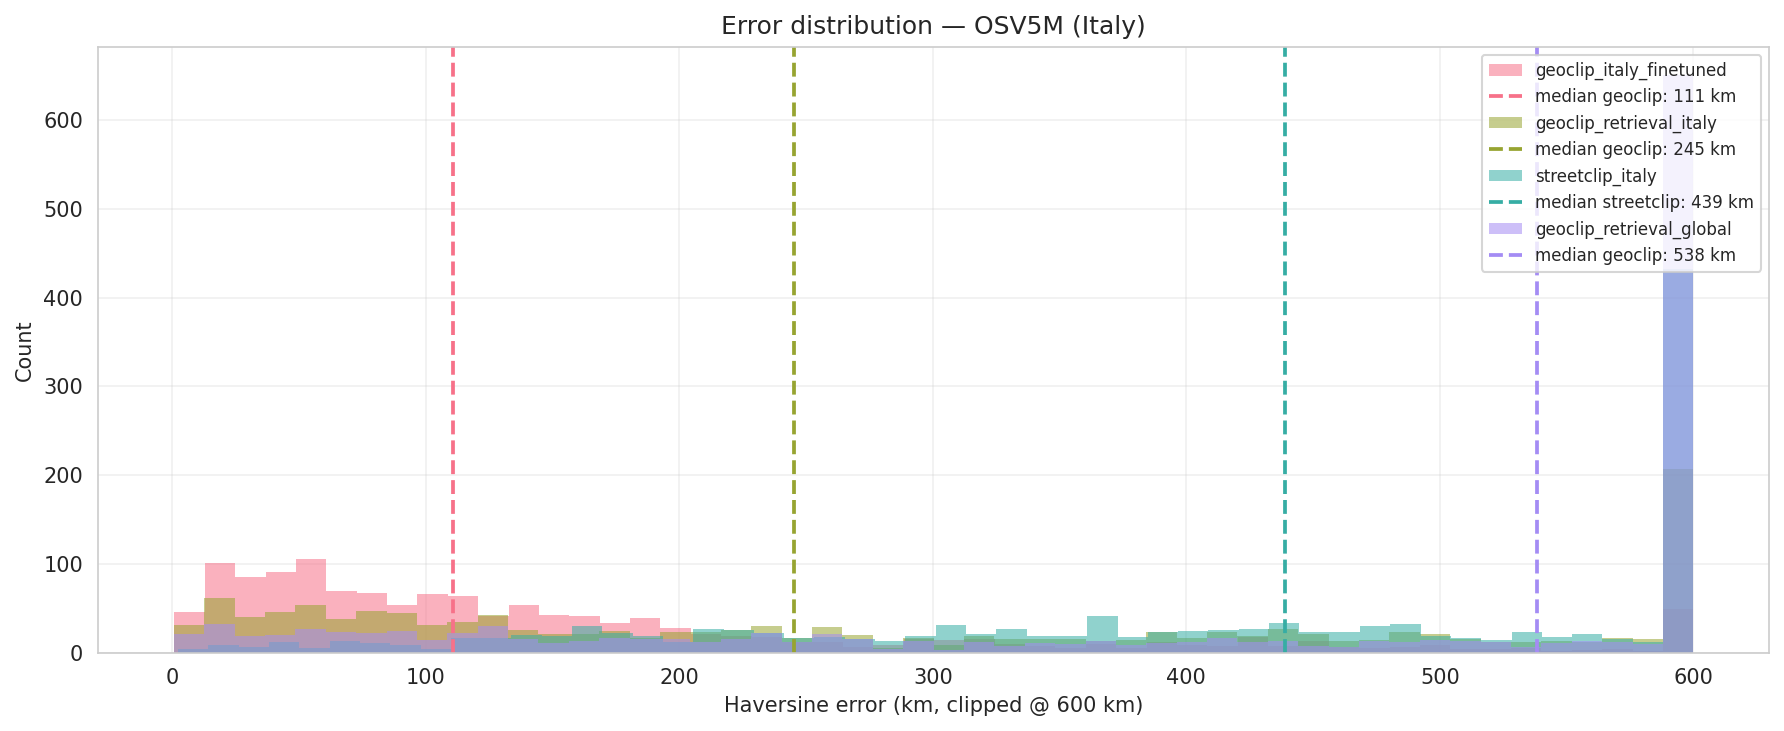


--- osv5m_metrics_summary.csv


,dataset,model,n,mean_km,median_km,p90_km,acc_1km_pct,acc_10km_pct,acc_25km_pct,acc_50km_pct,acc_100km_pct,acc_200km_pct,acc_500km_pct,acc_2500km_pct
0,osv5m,geoclip_italy_finetuned,1397,168.042435,110.817547,425.481909,0.071582,2.147459,10.594130,24.194703,45.669291,73.586256,94.273443,100.000000
1,osv5m,geoclip_retrieval_italy,1397,301.694488,245.217502,641.310044,0.143164,1.360057,6.800286,13.314245,26.771654,42.806013,77.523264,100.000000
2,osv5m,streetclip_italy,1397,467.946796,438.782742,823.897038,0.000000,0.286328,0.858984,2.362205,5.297065,16.607015,59.985684,100.000000
3,osv5m,geoclip_retrieval_global,1397,1290.467481,538.262661,1931.853560,0.143164,1.073729,3.937008,6.800286,14.030064,24.552613,47.244094,92.197566



--- osv5m_region_confusion.png


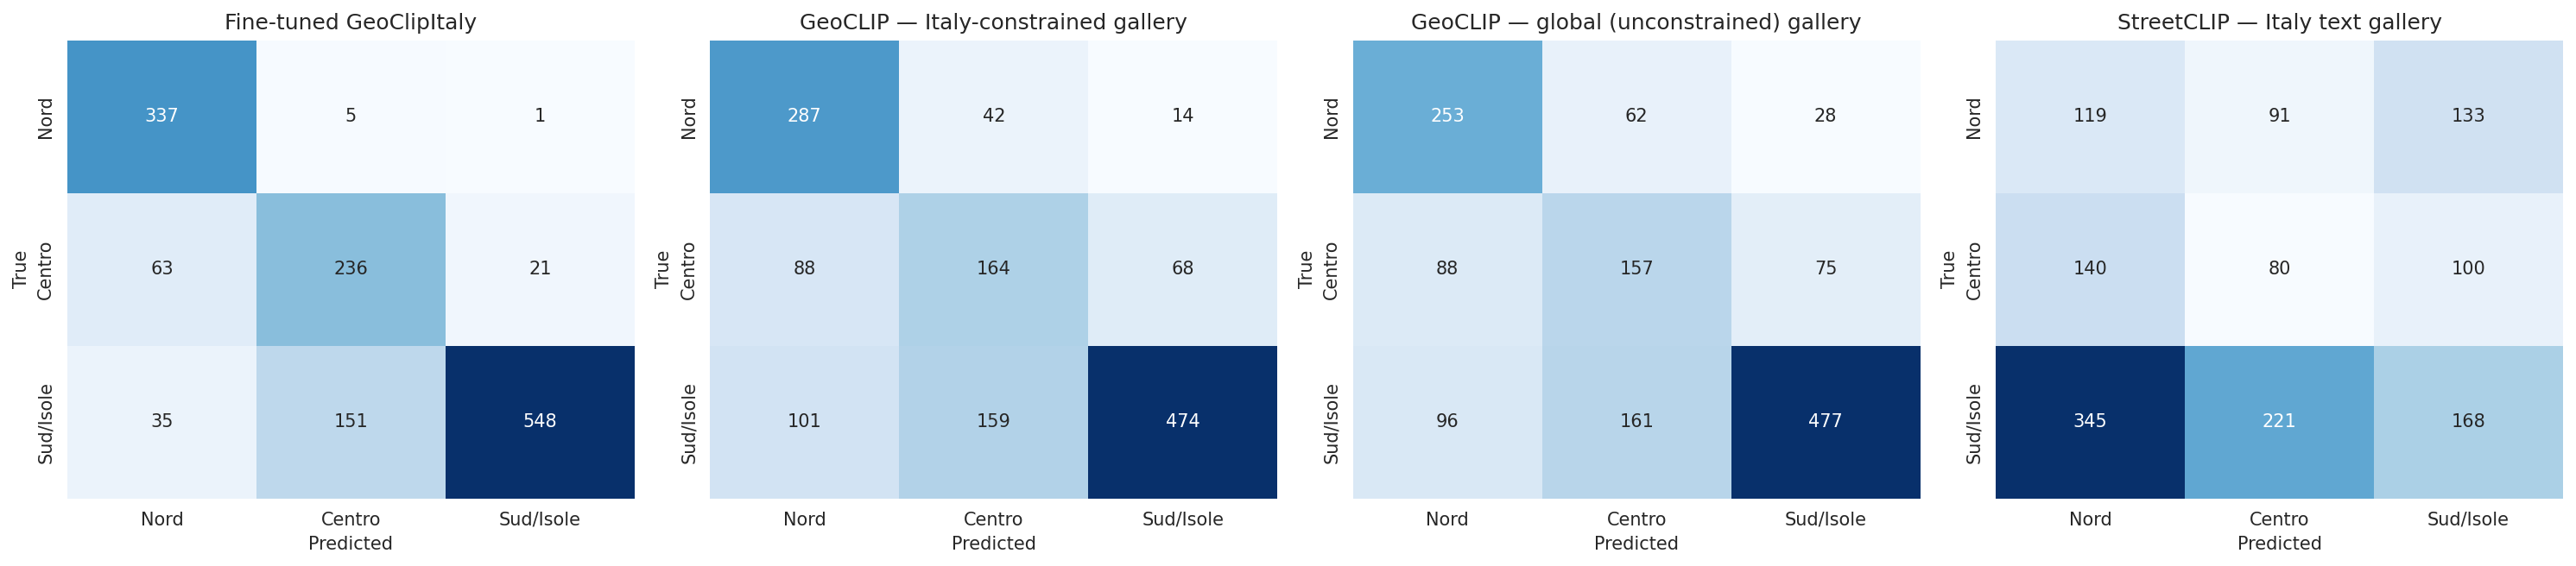


--- osv5m_scatter_by_model.png


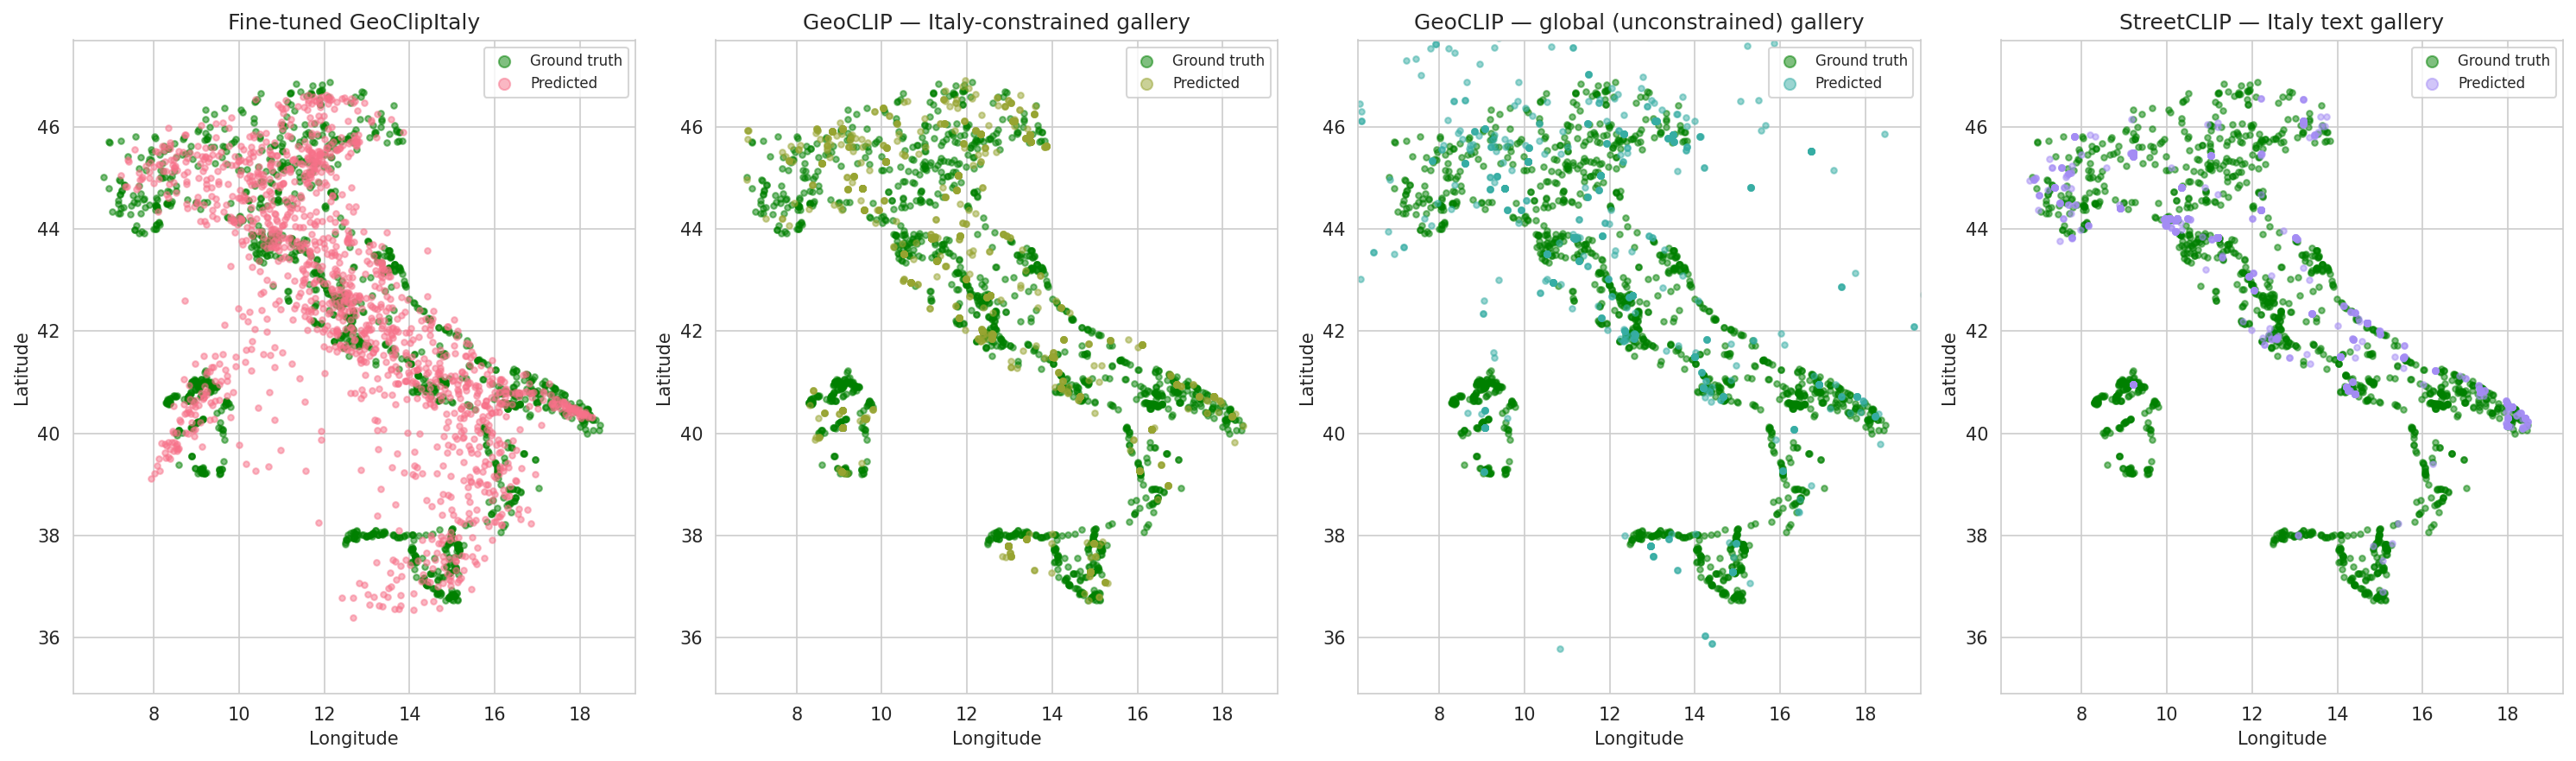

In [16]:
import os
import pandas as pd
from IPython.display import Image as IPImage, HTML, display
from benchmarking.visualization import save_results_bundle
from benchmarking.metrics       import paper_metrics_table

# Save per-model prediction CSVs + metrics summary CSV
for dataset_name, dataset_results in results.items():
    save_results_bundle(dataset_results, cfg.output_dir, dataset_name)

    # Paper-format CSV for easy comparison with GeoCLIP paper Table 1
    paper_df = paper_metrics_table(dataset_results)
    paper_path = os.path.join(cfg.output_dir, f"{dataset_name}_paper_metrics.csv")
    paper_df.to_csv(paper_path, index=False)
    print(f"GeoCLIP paper metrics ({dataset_name}) -> {paper_path}")
    display(paper_df)

# Display all generated artifacts
print(f"\nAll artifacts in: {cfg.output_dir}")
for fname in sorted(os.listdir(cfg.output_dir)):
    path = os.path.join(cfg.output_dir, fname)
    if fname.endswith(".png"):
        print(f"\n--- {fname}")
        display(IPImage(filename=path, width=800))
    elif fname.endswith(".html"):
        display(HTML(f'<a href="{path}" target="_blank">{fname}</a>'))
    elif fname.endswith("_summary.csv"):
        print(f"\n--- {fname}")
        try:
            display(pd.read_csv(path))
        except Exception:
            pass

## Section 6 — Regenerate Plots (Optional)

Run the cell below to re-draw all plots/maps from an existing `results` dict
(i.e., after inference already ran) without repeating model inference.

Saved CDF: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/osv5m_error_cdf.png
Saved failure map: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/osv5m_worst20_map.html
Saved CDF: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/im2gps_error_cdf.png
Saved failure map: /content/drive/MyDrive/Vision_Project_2026/benchmark_results/im2gps_worst20_map.html
Plots regenerated.


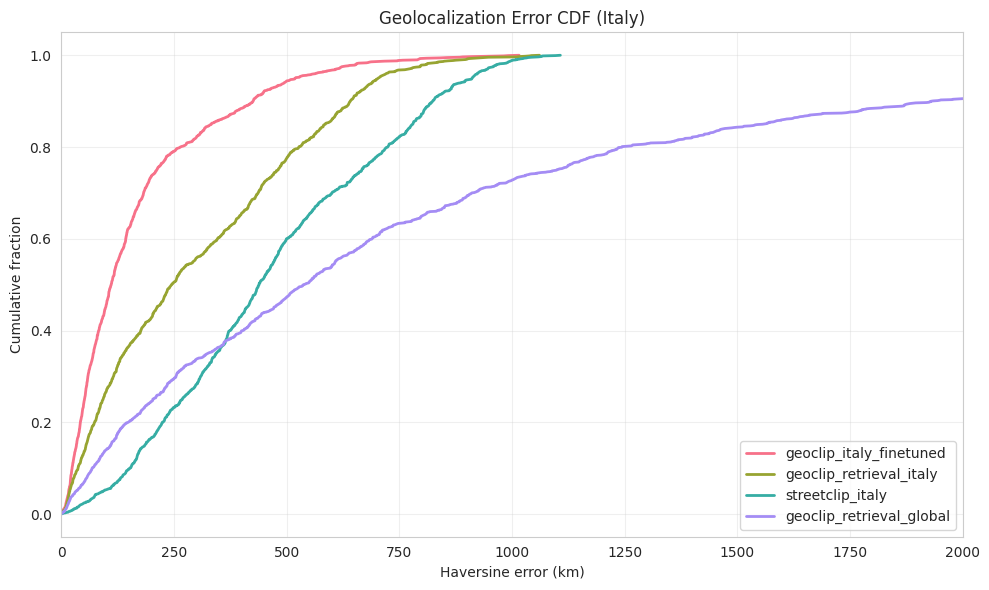

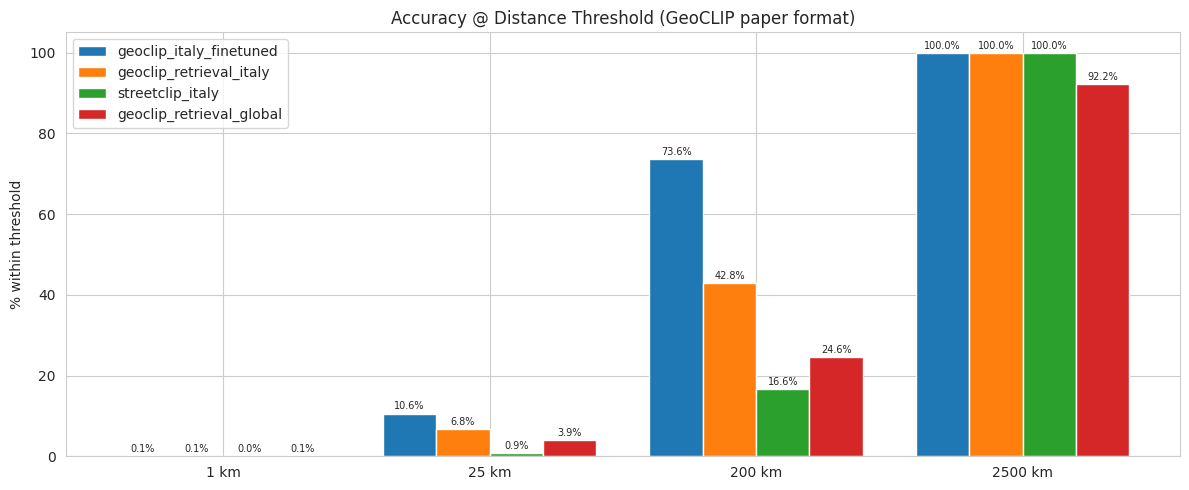

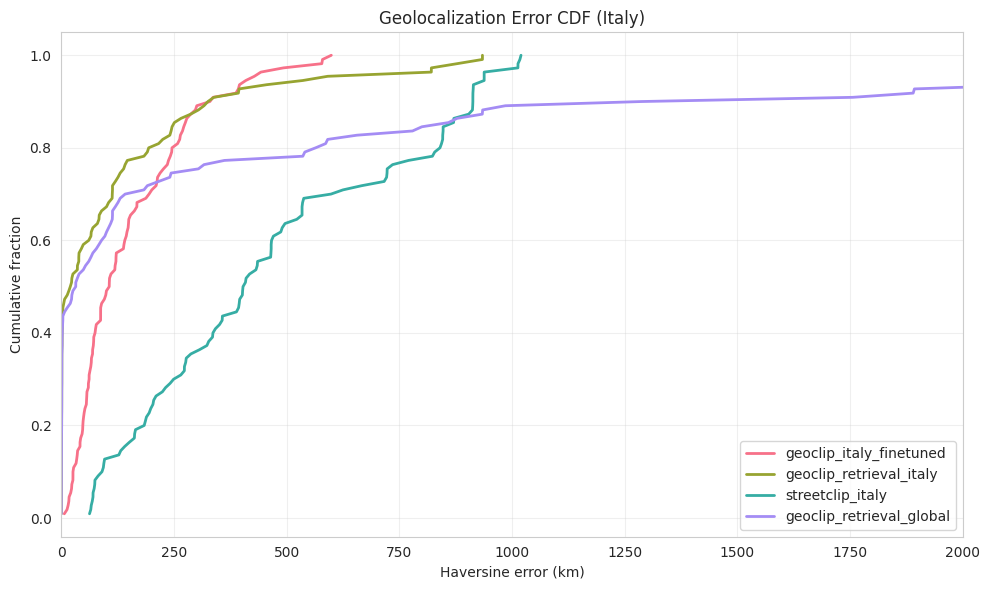

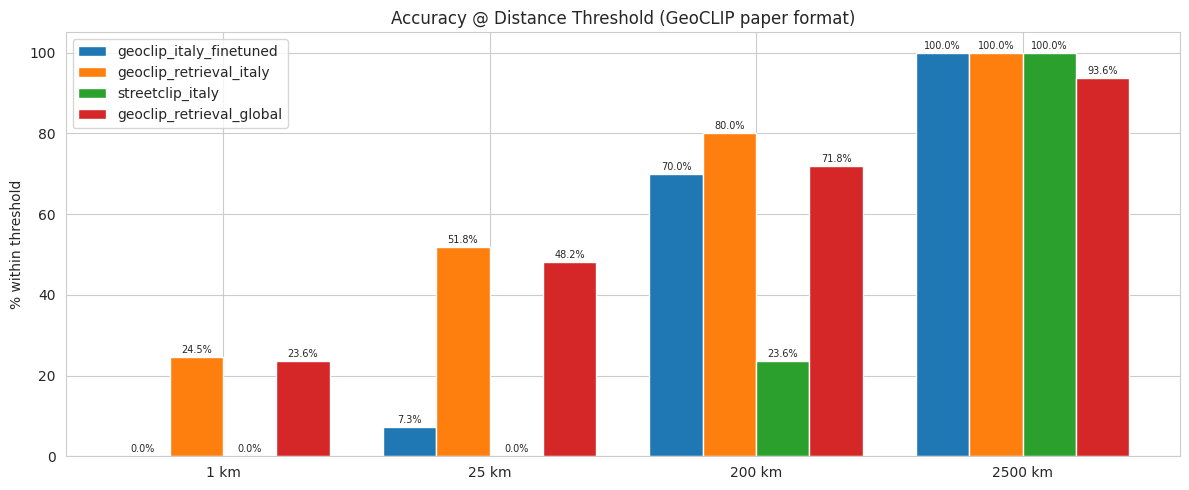

In [17]:
# Regenerate CDF, accuracy bars, and worst-case map from existing `results` dict.
# Useful if run_benchmark completed but a plot cell crashed, or you want to tweak styling.

from benchmarking.runner import regenerate_plots

if "results" in dir() and results:
    regenerate_plots(cfg, results)
    print("Plots regenerated.")
else:
    print("No results in scope. Run the inference cell first (Section 2).")

## Section 7 — Cross-Version Consistency Sweep (V3 → V3.3)

Runs every OSV5M-trained checkpoint (V3, V3.1, V3.2, V3.3, and V3.3+TTA) through the
*same* baselines, *same* test set, and *same* inference/metrics code as Sections 2–5
above, so every row in the resulting table is directly comparable. This replaces the
val-loss-only ablation (which mixes GLDv2-era and OSV5M-era numbers on different scales)
with a real held-out test-set metric (median km, accuracy@threshold) per version.

**V1 and V2 are intentionally excluded**: V1 uses a different architecture (no LoRA, a
smaller regression head) this loader can't read, and V2 — though loadable — was trained
on GLDv2, not OSV5M, so its numbers here would reflect cross-dataset transfer rather than
a fair ablation step. Both stay reported separately on the GLDv2 test split.

Runtime: roughly 5× a single-checkpoint pass (5 checkpoints, one with TTA) — budget
~1–2 hours on a T4. Set `N_TEST_SAMPLES` in Cell 02 to a small int first for a smoke test.

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display
from benchmarking.sweep import default_version_specs, run_checkpoint_sweep
from benchmarking.metrics import paper_metrics_table
from benchmarking.visualization import plot_accuracy_bars, plot_error_cdf

sweep_results = run_checkpoint_sweep(
    cfg,
    version_specs=default_version_specs(cfg.drive_base),
    dataset_name="osv5m",
    include_italy_baseline=True,
    include_global_baseline=True,
    include_streetclip=INCLUDE_STREETCLIP,
)

sweep_order = [
    "geoclip_retrieval_global", "geoclip_retrieval_italy", "streetclip_italy",
    "V3", "V3.1", "V3.2", "V3.3", "V3.3 + TTA",
]
present = [k for k in sweep_order if k in sweep_results and not sweep_results[k].empty]

print("\nConsistent cross-version comparison (OSV5M fixed test set, 1,397 images):")
sweep_table = paper_metrics_table({k: sweep_results[k] for k in present})
display(sweep_table)

sweep_csv = f"{cfg.output_dir}/osv5m_version_sweep_metrics.csv"
sweep_table.to_csv(sweep_csv, index=False)
print(f"Saved: {sweep_csv}")

plot_error_cdf(
    {k: sweep_results[k] for k in present},
    output_path=f"{cfg.output_dir}/osv5m_version_sweep_cdf.png",
    max_km=500.0, title="Error CDF across versions (OSV5M Italy)",
)
plt.show()

plot_accuracy_bars(
    {k: sweep_results[k] for k in present},
    output_path=f"{cfg.output_dir}/osv5m_version_sweep_accuracy_bars.png",
    thresholds_km=(1, 25, 100, 200),
    title="Accuracy @ threshold across versions (OSV5M Italy)",
)
plt.show()

deploy test:   0%|          | 0/20 [00:00<?, ?bucket/s]

[test] 1,397 images ready in 0.1s


OSV5M test Italy:   0%|          | 0/1397 [00:00<?, ?rows/s]

OSV5M test: 1,397 / 1,397 images found on disk
[sweep] osv5m: 1,397 samples


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

...

V3.3:   0%|          | 0/44 [00:00<?, ?it/s]


  V3.3
    N            : 1,397
    Mean error   : 183.92 km
    Median error : 119.72 km
    90th pct     : 459.65 km
    --- Accuracy @ threshold ---
    Within     1 km : 0.1%
    Within    10 km : 2.1%
    Within    25 km : 8.8%
    Within    50 km : 21.6%
    Within   100 km : 43.7%
    Within   200 km : 68.9%
    Within   500 km : 92.6%
    Within  2500 km : 100.0%


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Loaded fine-tuned checkpoint: /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_3/geoclip_italy_BEST.pth


V3.3 + TTA:   0%|          | 0/44 [00:00<?, ?it/s]